In [62]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [63]:
#Importações
import sys
from pathlib import Path, PosixPath
from copy import deepcopy

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import orjson
import pandas as pd
from IPython.display import display
from mplsoccer import Pitch
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from tqdm.auto import tqdm
import seaborn as sns

import gandula
from gandula.providers.pff.schema.gradient_event import GradientEventRow

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [64]:
MAX_FILES = None
PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
TEST_SIZE = 0.20
RANDOM_SEED = 42
MONTE_CARLO_SIMS = 20_000
MONTE_CARLO_MAX_STEPS = 25
XT_BINS = (16, 12)
XT_TOL = 1e-6
XT_MAX_ITERS = 200
HORIZON_ACTIONS = 10

In [65]:
#LEITURA DAS TABELAS PARCIAIS GERADAS PARA FACILITAR A LEITURA
PASTA_DADOS = Path('dados')

print("⏳ Carregando suas tabelas a partir da pasta 'dados'...")

# Leitura dos arquivos
actions_df = pd.read_csv(PASTA_DADOS / 'actions_df_24_25.csv')
all_value_events_df = pd.read_csv(PASTA_DADOS / 'eventos_valor_limpos_24_25.csv')
lightweight_processing_df = pd.read_csv(PASTA_DADOS / 'lightweight_processing_df_24_25.csv')
substitutions_df = pd.read_csv(PASTA_DADOS / 'substitutions_df_24_25.csv')

print("✅ Todas as tabelas carregadas com sucesso!")

# Verificação rápida
print(f"Total de ações: {len(actions_df):,}")
print(f"Total de substituições: {len(substitutions_df):,}")

# Diagnóstico para confirmar que carregou tudo certo
print(f"✅ Extração Concluída (Via Checkpoint)!")
print(f"Total de Substituições Prontas: {len(substitutions_df):,}")
print(f"Total de Eventos de Valor Extraídos: {len(all_value_events_df):,}")

# Opcional: Mostra os gols para confirmar que está tudo OK
chutes_df = all_value_events_df[all_value_events_df['possession_events_possession_event_type'] == 'SH']
print("\n--- Resultados dos Chutes (Shot Outcomes) ---")
print(chutes_df['possession_events_shot_outcome_type'].value_counts())

⏳ Carregando suas tabelas a partir da pasta 'dados'...
✅ Todas as tabelas carregadas com sucesso!
Total de ações: 762,325
Total de substituições: 3,207
✅ Extração Concluída (Via Checkpoint)!
Total de Substituições Prontas: 3,207
Total de Eventos de Valor Extraídos: 397,818

--- Resultados dos Chutes (Shot Outcomes) ---
possession_events_shot_outcome_type
O    3429
B    2858
S    2292
G    1211
C     218
F      78
L      56
Name: count, dtype: int64


In [66]:
EVENTS_DIR = Path('dados')
players_df = pd.read_json(
    EVENTS_DIR / 'players.json'
)

In [67]:
player_names = players_df[
    ['id', 'nickname']
].drop_duplicates()

In [68]:
substitutions_df.head()

,match_id,competition_name,season,game_event_id,period,start_time,end_time,player_on_id,player_off_id,minute,player_on_name,player_off_name,team_id
0,31995,Premier League,2024-2025,24426845,2,"3,801.7020","3,801.7020","9,914.0000",105.0000,63,Joshua Zirkzee,Mason Mount,12.0000
1,31995,Premier League,2024-2025,24426846,2,"3,803.5700","3,803.5700","7,832.0000","2,123.0000",63,Alejandro Garnacho,Amad Diallo,12.0000
2,31995,Premier League,2024-2025,24426847,2,"3,994.3610","3,994.3610","1,981.0000","2,118.0000",66,Tom Cairney,Emile Smith Rowe,54.0000
3,31995,Premier League,2024-2025,24426848,2,"4,865.5990","4,865.5990",308.0000,250.0000,81,Harry Wilson,Adama Traoré,54.0000
4,31995,Premier League,2024-2025,24426849,2,"4,871.8720","4,871.8720",252.0000,"7,220.0000",81,Raúl Jiménez,Rodrigo Muniz,54.0000


In [69]:

ACTION_TYPE_MAP = {
    'PA': 'pass',
    'CR': 'cross',
    'BC': 'carry',
    'SH': 'shot',
    'IT': 'interception',
    'CH': 'challenge',
    'CL': 'clearance',
    'RE': 'rebound',
    'TC': 'touch_control',
    'FO': 'foul',
}

XT_ACTION_TYPES = ['pass', 'cross', 'carry', 'shot']



def _first_notna(*values):
    for value in values:
        if pd.notna(value):
            return value
    return np.nan



def _coerce_int(value):
    if pd.isna(value):
        return np.nan
    try:
        return int(value)
    except (TypeError, ValueError):
        return np.nan



def _safe_ball_xy(ball_snapshot):
    if not isinstance(ball_snapshot, list) or len(ball_snapshot) == 0:
        return np.nan, np.nan
    ball = ball_snapshot[0] or {}
    return ball.get('x', np.nan), ball.get('y', np.nan)




def _find_player_snapshot(row_dict, player_id):
    return _find_player_in_snapshots(row_dict.get('home_players'), row_dict.get('away_players'), player_id)



def _snapshot_with_coords(player_snapshot):
    if player_snapshot is None:
        return None
    x = player_snapshot.get('x', np.nan)
    y = player_snapshot.get('y', np.nan)
    if pd.isna(x) or pd.isna(y):
        return None
    return player_snapshot



def _executor_player_id(row_dict):
    event_type = row_dict.get('possession_events_possession_event_type')
    candidates = {
        'PA': [row_dict.get('possession_events_passer_player_id'), row_dict.get('game_events_player_id')],
        'CR': [row_dict.get('possession_events_crosser_player_id'), row_dict.get('game_events_player_id')],
        'BC': [
            row_dict.get('possession_events_ball_carrier_player_id'),
            row_dict.get('possession_events_carrier_player_id'),
            row_dict.get('game_events_player_id'),
        ],
        'SH': [row_dict.get('possession_events_shooter_player_id'), row_dict.get('game_events_player_id')],
        'CL': [row_dict.get('possession_events_clearer_player_id'), row_dict.get('game_events_player_id')],
        'RE': [row_dict.get('possession_events_rebounder_player_id'), row_dict.get('game_events_player_id')],
        'TC': [row_dict.get('possession_events_touch_player_id'), row_dict.get('game_events_player_id')],
        'CH': [row_dict.get('possession_events_challenger_player_id'), row_dict.get('game_events_player_id')],
        'IT': [row_dict.get('game_events_player_id')],
        'FO': [row_dict.get('game_events_player_id')],
    }.get(event_type, [row_dict.get('game_events_player_id')])

    return _first_notna(*candidates)



def _target_player_id(row_dict):
    event_type = row_dict.get('possession_events_possession_event_type')
    candidates = {
        'PA': [
            row_dict.get('possession_events_target_player_id'),
            row_dict.get('possession_events_receiver_player_id'),
        ],
        'CR': [row_dict.get('possession_events_target_player_id')],
        'BC': [
            row_dict.get('possession_events_target_player_id'),
            row_dict.get('possession_events_movement_player_id'),
            row_dict.get('possession_events_ball_carrier_player_id'),
            row_dict.get('possession_events_carrier_player_id'),
        ],
        'SH': [],
        'IT': [],
        'CH': [],
        'CL': [],
        'RE': [],
        'TC': [],
        'FO': [],
    }.get(event_type, [])

    return _first_notna(*candidates)



def _reverse_direction(direction):
    return 'L' if direction == 'R' else 'R'



def _infer_attack_direction(row_dict):
    direction = row_dict.get('stadium_metadata_team_attacking_direction')
    if isinstance(direction, str) and direction in {'L', 'R'}:
        return direction

    home_team = row_dict.get('game_events_home_team')
    period = row_dict.get('game_events_period')
    home_team_start_left = row_dict.get('stadium_metadata_home_team_start_left')

    if pd.isna(home_team) or pd.isna(period) or pd.isna(home_team_start_left):
        return np.nan

    period = int(period)
    home_team_start_left = bool(home_team_start_left)
    home_attacks_right_p1 = home_team_start_left
    home_direction = 'R' if home_attacks_right_p1 else 'L'

    if period % 2 == 0:
        home_direction = _reverse_direction(home_direction)

    return home_direction if bool(home_team) else _reverse_direction(home_direction)



def _orient_center_coordinates(x, y, attack_direction):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    if attack_direction == 'L':
        return -x, -y
    return x, y



def _centre_to_pitch(x, y, pitch_length=PITCH_LENGTH, pitch_width=PITCH_WIDTH):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    x_pitch = np.clip(x + pitch_length / 2.0, 0.0, pitch_length)
    y_pitch = np.clip(y + pitch_width / 2.0, 0.0, pitch_width)
    return x_pitch, y_pitch



def _raw_outcome(row_dict, action_code):
    outcome_map = {
        'PA': 'possession_events_pass_outcome_type',
        'CR': 'possession_events_cross_outcome_type',
        'BC': 'possession_events_ball_carry_outcome',
        'SH': 'possession_events_shot_outcome_type',
        'CH': 'possession_events_challenge_outcome_type',
        'CL': 'possession_events_clearance_outcome_type',
        'RE': 'possession_events_rebound_outcome_type',
        'TC': 'possession_events_touch_outcome_type',
        'FO': 'fouls_final_foul_outcome_type',
    }
    col = outcome_map.get(action_code)
    return row_dict.get(col) if col is not None else np.nan



def _future_target_snapshot_from_events(records, row_idx, target_player_id, max_seconds=5.0, control_radius=2.0):
    if pd.isna(target_player_id):
        return None

    current_row = records[row_idx]
    match_id = current_row.get('game_id')
    period = current_row.get('game_events_period')
    start_time = current_row.get('start_time')

    best_snapshot = None
    best_distance = np.inf

    for future_row in records[row_idx + 1:]:
        if future_row.get('game_id') != match_id:
            break

        future_period = future_row.get('game_events_period')
        if pd.notna(period) and pd.notna(future_period):
            base_period = int(period)
            future_period = int(future_period)
            if future_period < base_period:
                continue
            if future_period > base_period:
                break

        if pd.notna(start_time) and pd.notna(future_row.get('start_time')):
            delta_t = float(future_row.get('start_time')) - float(start_time)
            if delta_t < 0:
                continue
            if delta_t > max_seconds:
                break

        target_snapshot = _snapshot_with_coords(_find_player_snapshot(future_row, target_player_id))
        if target_snapshot is None:
            continue

        ball_x, ball_y = _safe_ball_xy(future_row.get('ball'))
        if pd.notna(ball_x) and pd.notna(ball_y):
            ball_distance = float(np.hypot(ball_x - target_snapshot['x'], ball_y - target_snapshot['y']))
            if ball_distance <= control_radius:
                return target_snapshot
            if ball_distance < best_distance:
                best_distance = ball_distance
                best_snapshot = target_snapshot
        elif best_snapshot is None:
            best_snapshot = target_snapshot

    return best_snapshot



def build_actions_from_events(flat_events_df):
    rows = []
    records = flat_events_df.to_dict('records')

    for row_idx, row_dict in enumerate(records):
        action_code = row_dict.get('possession_events_possession_event_type')
        if action_code not in ACTION_TYPE_MAP:
            continue

        action_type = ACTION_TYPE_MAP[action_code]
        executor_player_id = _executor_player_id(row_dict)
        executor_snapshot = _snapshot_with_coords(_find_player_snapshot(row_dict, executor_player_id))
        target_player_id = _target_player_id(row_dict)
        same_event_target_snapshot = _snapshot_with_coords(_find_player_snapshot(row_dict, target_player_id))

        future_target_snapshot = None
        if action_type in {'pass', 'cross', 'carry'}:
            future_target_snapshot = _future_target_snapshot_from_events(records, row_idx, target_player_id)

        target_snapshot = future_target_snapshot or same_event_target_snapshot
        endpoint_source = 'future_event_snapshot' if future_target_snapshot is not None else 'same_event_snapshot'
        if target_snapshot is None:
            endpoint_source = 'missing'

        start_x_center, start_y_center = _safe_ball_xy(row_dict.get('ball'))
        if (pd.isna(start_x_center) or pd.isna(start_y_center)) and executor_snapshot is not None:
            start_x_center = executor_snapshot.get('x', np.nan)
            start_y_center = executor_snapshot.get('y', np.nan)

        if target_snapshot is None:
            end_x_center, end_y_center = np.nan, np.nan
        else:
            end_x_center = target_snapshot.get('x', np.nan)
            end_y_center = target_snapshot.get('y', np.nan)

        attack_direction = _infer_attack_direction(row_dict)
        start_x_center, start_y_center = _orient_center_coordinates(start_x_center, start_y_center, attack_direction)
        end_x_center, end_y_center = _orient_center_coordinates(end_x_center, end_y_center, attack_direction)

        start_x, start_y = _centre_to_pitch(start_x_center, start_y_center)
        end_x, end_y = _centre_to_pitch(end_x_center, end_y_center)

        raw_outcome = _raw_outcome(row_dict, action_code)
        goal = int(action_type == 'shot' and raw_outcome == 'G')

        if action_type == 'pass':
            success = int(raw_outcome == 'C')
        elif action_type == 'cross':
            success = int(raw_outcome == 'C')
        elif action_type == 'carry':
            success = int(raw_outcome in {'R', 'L', 'C'} or target_snapshot is not None)
        elif action_type == 'shot':
            success = goal
        else:
            success = np.nan

        rows.append(
            {
                'match_id': _coerce_int(row_dict.get('game_id')),
                'competition_name': row_dict.get('competition_name'),
                'season': row_dict.get('season'),
                'game_event_id': _coerce_int(row_dict.get('game_event_id')),
                'possession_event_id': _coerce_int(row_dict.get('possession_event_id')),
                'sequence': row_dict.get('sequence'),
                'start_time': row_dict.get('start_time'),
                'end_time': row_dict.get('end_time'),
                'period': _coerce_int(row_dict.get('game_events_period')),
                'team_id': _coerce_int(row_dict.get('game_events_team_id')),
                'home_team': row_dict.get('game_events_home_team'),
                'team_side': 'home' if bool(row_dict.get('game_events_home_team')) else 'away',
                'player_id': _coerce_int(executor_player_id),
                'target_player_id': _coerce_int(target_player_id),
                'action_code': action_code,
                'action_type': action_type,
                'attack_direction': attack_direction,
                'endpoint_source': endpoint_source,
                'x': start_x,
                'y': start_y,
                'x_end': end_x,
                'y_end': end_y,
                'success': success,
                'goal': goal,
                'raw_outcome': raw_outcome,
            }
        )

    actions = pd.DataFrame(rows)
    actions = actions.sort_values(['match_id', 'period', 'start_time', 'game_event_id']).reset_index(drop=True)
    return actions


def build_actions_table_from_paths(paths):
    action_tables = []
    processing_rows = []

    for path in tqdm(paths, desc='Carregando todos os arquivos de forma leve', leave=False):
        light_events_df = load_light_events_df(path)
        action_df = build_actions_from_events(light_events_df)
        action_tables.append(action_df)
        processing_rows.append(
            {
                'file_name': Path(path).name,
                'n_action_events_after_slim': len(light_events_df),
                'n_actions_final': len(action_df),
                'n_slim_columns': len(light_events_df.columns),
            }
        )
        del light_events_df

    actions_df = pd.concat(action_tables, ignore_index=True)
    actions_df = actions_df.sort_values(['match_id', 'period', 'start_time', 'game_event_id']).reset_index(drop=True)
    processing_df = pd.DataFrame(processing_rows)
    return actions_df, processing_df


In [70]:

#actions_df, lightweight_processing_df = build_actions_table_from_paths(event_paths)

print('Nao concatenamos o dataframe completo de eventos para todos os jogos.')
print('Cada arquivo foi achatado, reduzido ao minimo necessario para a aula e descartado em seguida.')
display(lightweight_processing_df.head(10))

modeling_view_cols = [
    'match_id',
    'game_event_id',
    'action_type',
    'x',
    'y',
    'x_end',
    'y_end',
    'success',
    'goal',
    'attack_direction',
]
display(actions_df[modeling_view_cols].head(10))

coverage_rows = []
for action_type, group in actions_df.groupby('action_type'):
    coverage_rows.append(
        {
            'action_type': action_type,
            'n_actions': len(group),
            'start_coord_coverage': group[['x', 'y']].notna().all(axis=1).mean(),
            'end_coord_coverage': group[['x_end', 'y_end']].notna().all(axis=1).mean(),
            'success_rate': group['success'].mean(),
            'goal_rate': group['goal'].mean(),
        }
    )
coverage_df = pd.DataFrame(coverage_rows).sort_values('n_actions', ascending=False).reset_index(drop=True)

display(coverage_df)
display(
    actions_df[['action_type', 'raw_outcome']]
    .value_counts(dropna=False)
    .rename('n')
    .reset_index()
    .head(20)
)


Nao concatenamos o dataframe completo de eventos para todos os jogos.
Cada arquivo foi achatado, reduzido ao minimo necessario para a aula e descartado em seguida.


,file_name,n_action_events_after_slim,n_actions_final,n_slim_columns
0,32272.json,1962,1962,39
1,32048.json,2053,2053,39
2,31996.json,2012,2012,39
3,32112.json,2183,2183,39
4,32100.json,2127,2127,39
5,32111.json,2050,2050,39
6,32098.json,2107,2107,39
7,32231.json,1902,1902,39
8,32068.json,2145,2145,39
9,32275.json,1937,1937,39


,match_id,game_event_id,action_type,x,y,x_end,y_end,success,goal,attack_direction
0,31995,24426842,pass,50.8400,33.8900,43.1510,33.9450,1.0000,0,L
1,31995,24426890,interception,44.5400,33.5300,NaN,NaN,NaN,0,L
2,31995,24426890,pass,42.4200,31.3200,27.5670,27.5560,1.0000,0,L
3,31995,24426892,interception,28.0500,27.1700,NaN,NaN,NaN,0,L
4,31995,24426892,pass,31.3400,11.5800,62.3120,1.6840,1.0000,0,L
5,31995,24426893,touch_control,64.4500,6.3100,NaN,NaN,NaN,0,L
6,31995,24426895,challenge,43.5400,57.5900,NaN,NaN,NaN,0,R
7,31995,24426895,pass,39.2200,66.7700,46.2200,67.0660,1.0000,0,R
8,31995,24426897,interception,46.0000,66.8300,NaN,NaN,NaN,0,R
9,31995,24426897,pass,48.1600,66.2000,52.4300,63.1670,0.0000,0,R


,action_type,n_actions,start_coord_coverage,end_coord_coverage,success_rate,goal_rate
0,pass,356552,1.0000,0.9998,0.8347,0.0000
1,interception,257558,1.0000,0.0000,NaN,0.0000
2,challenge,66681,0.9996,0.0000,NaN,0.0000
3,clearance,16802,1.0000,0.0000,NaN,0.0000
4,carry,15673,1.0000,1.0000,1.0000,0.0000
5,rebound,15584,1.0000,0.0000,NaN,0.0000
6,cross,15451,1.0000,0.9375,0.2227,0.0000
7,shot,10142,1.0000,0.0000,0.1194,0.1194
8,touch_control,7627,1.0000,0.0000,NaN,0.0000
9,foul,255,0.9569,0.0000,NaN,0.0000


,action_type,raw_outcome,n
0,pass,C,297615
1,interception,NaN,257558
2,pass,D,44269
3,challenge,R,21180
4,challenge,D,18367
5,carry,R,13691
6,challenge,P,11055
7,clearance,P,10857
8,rebound,P,10652
9,cross,D,8611


In [71]:
actions_df.columns

Index(['match_id', 'competition_name', 'season', 'game_event_id',
       'possession_event_id', 'sequence', 'start_time', 'end_time', 'period',
       'team_id', 'home_team', 'team_side', 'player_id', 'target_player_id',
       'action_code', 'action_type', 'attack_direction', 'endpoint_source',
       'x', 'y', 'x_end', 'y_end', 'success', 'goal', 'raw_outcome'],
      dtype='str')

In [72]:

FINAL_THIRD_START_X = 70.0
PENALTY_BOX_START_X = PITCH_LENGTH - 16.5
PENALTY_BOX_WIDTH_Y = 40.32
PENALTY_BOX_Y_MIN = (PITCH_WIDTH - PENALTY_BOX_WIDTH_Y) / 2.0
PENALTY_BOX_Y_MAX = PITCH_WIDTH - PENALTY_BOX_Y_MIN

TRANSIENT_STATES = [
    'build_up',
    'middle',
    'final_third_right',
    'final_third_middle',
    'final_third_left',
    'box',
]
ABSORBING_STATES = ['goal', 'loss']
SARAH_STATES = TRANSIENT_STATES + ABSORBING_STATES
RUDD_STATE_COLORS = {
    'build_up': '#d9e6f2',
    'middle': '#c7dced',
    'final_third_right': '#f6d6bd',
    'final_third_middle': '#f4b183',
    'final_third_left': '#f6d6bd',
    'box': '#de6a2c',
}



def make_match_split(match_ids, test_size=0.30, random_state=42):
    unique_ids = np.array(sorted(pd.unique(match_ids)))
    if len(unique_ids) < 2:
        raise ValueError('Precisamos de pelo menos 2 jogos para fazer avaliacao out-of-sample.')

    rng = np.random.default_rng(random_state)
    shuffled = unique_ids.copy()
    rng.shuffle(shuffled)

    n_test = max(1, int(np.ceil(len(shuffled) * test_size)))
    n_test = min(n_test, len(shuffled) - 1)

    test_ids = np.sort(shuffled[:n_test])
    train_ids = np.sort(shuffled[n_test:])
    return train_ids.tolist(), test_ids.tolist()



def add_sequence_goal_target(actions):
    df = actions.copy()
    df['sequence_goal'] = np.nan

    valid_mask = df['sequence'].notna() & df['team_id'].notna() & df['match_id'].notna()
    seq_goal = (
        df.loc[valid_mask]
        .groupby(['match_id', 'team_id', 'sequence'])['goal']
        .transform('max')
    )
    df.loc[valid_mask, 'sequence_goal'] = seq_goal.astype(float)
    return df



def div_no_nan(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.zeros_like(num, dtype=float)
    np.divide(num, den, out=out, where=den != 0)
    return out



def safe_roc_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)



def safe_roc_curve(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) < 2:
        return None
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds}



def evaluate_binary_predictions(y_true, y_prob, model_name, target_name):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    mask = pd.notna(y_true) & pd.notna(y_prob)
    y_true = y_true[mask].astype(int)
    y_prob = y_prob[mask].astype(float)
    y_prob = np.clip(y_prob, 1e-6, 1 - 1e-6)

    metrics = {
        'model': model_name,
        'target': target_name,
        'n': len(y_true),
        'positive_rate': y_true.mean() if len(y_true) else np.nan,
        'brier_score': brier_score_loss(y_true, y_prob) if len(y_true) else np.nan,
        'roc_auc': safe_roc_auc(y_true, y_prob) if len(y_true) else np.nan,
    }
    curve = safe_roc_curve(y_true, y_prob) if len(y_true) else None
    return metrics, curve



def plot_roc_curves(curve_specs, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    plotted = False

    for spec in curve_specs:
        curve = spec.get('curve')
        label = spec.get('label', 'modelo')
        auc = spec.get('auc', np.nan)
        if curve is None:
            continue
        plotted = True
        suffix = '' if pd.isna(auc) else f' (AUC = {auc:.3f})'
        ax.plot(curve['fpr'], curve['tpr'], linewidth=2, label=label + suffix)

    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    if plotted:
        ax.legend(loc='lower right')
    else:
        ax.text(0.5, 0.5, 'ROC indisponivel (apenas uma classe no teste).', ha='center', va='center')
    plt.show()


In [73]:

actions_df = add_sequence_goal_target(actions_df)
train_match_ids, test_match_ids = make_match_split(
    actions_df['match_id'].dropna().unique(),
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
)

split_summary = pd.DataFrame(
    {
        'split': ['train', 'test'],
        'n_matches': [len(train_match_ids), len(test_match_ids)],
        'n_actions': [
            actions_df['match_id'].isin(train_match_ids).sum(),
            actions_df['match_id'].isin(test_match_ids).sum(),
        ],
        'positive_rate_sequence_goal': [
            actions_df.loc[actions_df['match_id'].isin(train_match_ids), 'sequence_goal'].mean(),
            actions_df.loc[actions_df['match_id'].isin(test_match_ids), 'sequence_goal'].mean(),
        ],
    }
)

display(split_summary)


,split,n_matches,n_actions,positive_rate_sequence_goal
0,train,304,609055,0.0171
1,test,76,153270,0.0174


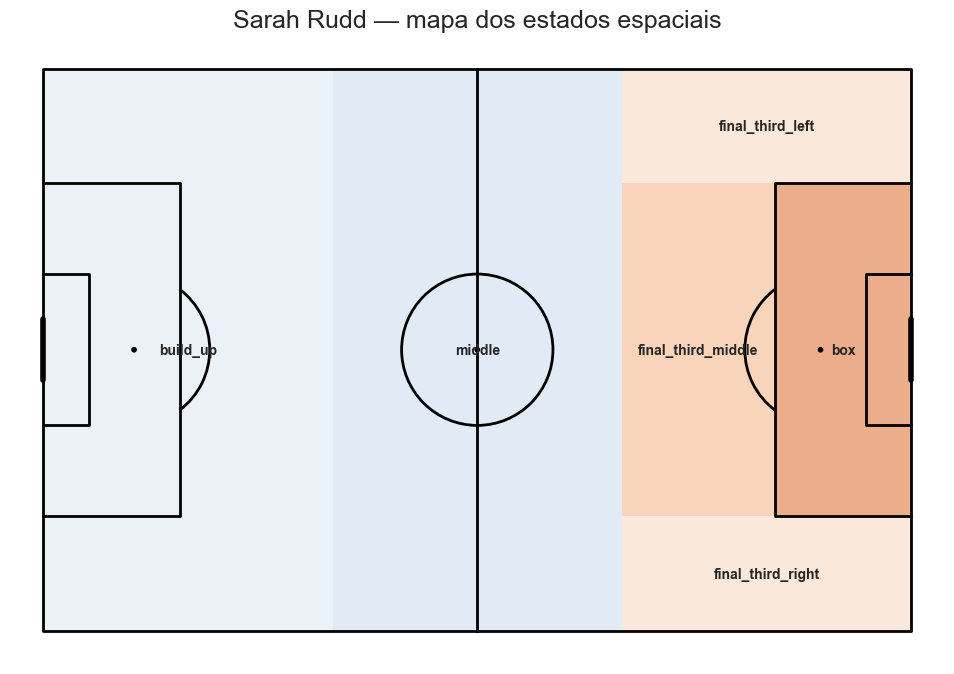

,build_up,middle,final_third_right,final_third_middle,final_third_left,box,goal,loss
build_up,"53,079.0000","16,183.0000",117.0000,227.0000,149.0000,14.0000,0.0000,"16,625.0000"
middle,"12,201.0000","96,636.0000","4,715.0000","5,158.0000","5,108.0000",527.0000,5.0000,"20,292.0000"
final_third_right,10.0000,"2,624.0000","8,758.0000","2,595.0000",14.0000,"1,546.0000",1.0000,"4,909.0000"
final_third_middle,28.0000,"2,895.0000","2,758.0000","10,824.0000","2,838.0000","2,355.0000",75.0000,"7,218.0000"
final_third_left,11.0000,"2,986.0000",15.0000,"2,879.0000","9,710.0000","1,588.0000",0.0000,"4,994.0000"
box,2.0000,9.0000,238.0000,858.0000,259.0000,"2,861.0000",882.0000,"9,848.0000"


,algebra_linear,iteracao,monte_carlo
build_up,0.0039,0.0039,0.0040
middle,0.0073,0.0073,0.0069
final_third_right,0.0161,0.0161,0.0175
final_third_middle,0.0200,0.0200,0.0200
final_third_left,0.0159,0.0159,0.0165
box,0.0750,0.0750,0.0757


,model,target,n,positive_rate,brier_score,roc_auc
0,sarah_algebra_linear,sequence_goal,80134,0.0193,0.0186,0.6637
1,sarah_iteracao,sequence_goal,80134,0.0193,0.0186,0.6637
2,sarah_monte_carlo,sequence_goal,80134,0.0193,0.0187,0.6637


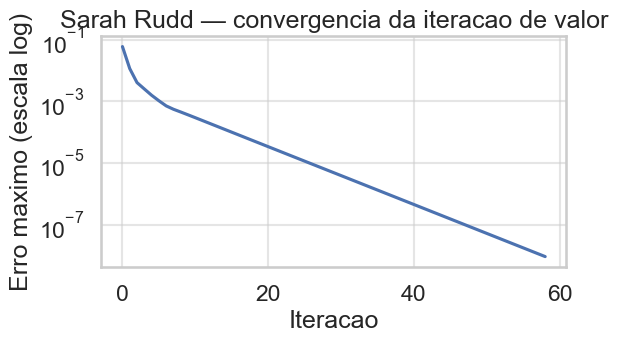

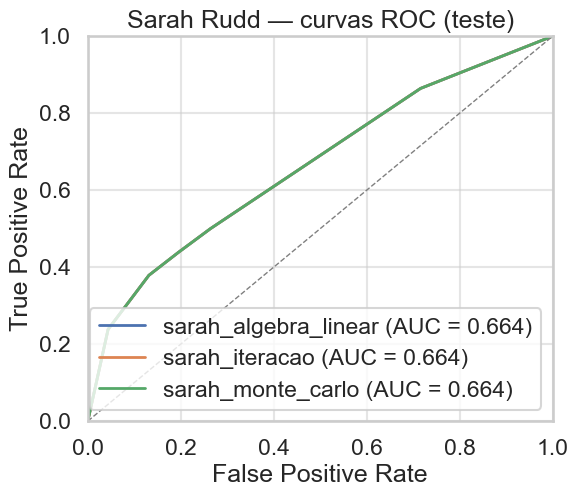

In [74]:

def rudd_state_from_xy(x, y):
    if pd.isna(x) or pd.isna(y):
        return np.nan
    if x < 35.0:
        return 'build_up'
    if x < FINAL_THIRD_START_X:
        return 'middle'
    in_penalty_lane = PENALTY_BOX_Y_MIN <= y <= PENALTY_BOX_Y_MAX
    if x >= PENALTY_BOX_START_X and in_penalty_lane:
        return 'box'
    if in_penalty_lane:
        return 'final_third_middle'
    if y > PENALTY_BOX_Y_MAX:
        return 'final_third_left'
    return 'final_third_right'



def plot_rudd_state_map():
    pitch = Pitch(
        pitch_type='custom',
        pitch_length=PITCH_LENGTH,
        pitch_width=PITCH_WIDTH,
        line_color='black',
    )
    fig, ax = pitch.draw(figsize=(10, 7))

    rectangles = [
        ('build_up', 0.0, 0.0, 35.0, PITCH_WIDTH),
        ('middle', 35.0, 0.0, FINAL_THIRD_START_X - 35.0, PITCH_WIDTH),
        ('final_third_right', FINAL_THIRD_START_X, 0.0, PITCH_LENGTH - FINAL_THIRD_START_X, PENALTY_BOX_Y_MIN),
        ('final_third_middle', FINAL_THIRD_START_X, PENALTY_BOX_Y_MIN, PENALTY_BOX_START_X - FINAL_THIRD_START_X, PENALTY_BOX_WIDTH_Y),
        ('final_third_left', FINAL_THIRD_START_X, PENALTY_BOX_Y_MAX, PITCH_LENGTH - FINAL_THIRD_START_X, PITCH_WIDTH - PENALTY_BOX_Y_MAX),
        ('box', PENALTY_BOX_START_X, PENALTY_BOX_Y_MIN, PITCH_LENGTH - PENALTY_BOX_START_X, PENALTY_BOX_WIDTH_Y),
    ]

    for state, x0, y0, width, height in rectangles:
        ax.add_patch(
            Rectangle(
                (x0, y0),
                width,
                height,
                facecolor=RUDD_STATE_COLORS[state],
                edgecolor='none',
                alpha=0.55,
                zorder=0,
            )
        )
        ax.text(
            x0 + width / 2.0,
            y0 + height / 2.0,
            state,
            ha='center',
            va='center',
            fontsize=10,
            weight='bold',
        )

    ax.set_title('Sarah Rudd — mapa dos estados espaciais')
    plt.show()



def build_rudd_dataset(actions):
    df = actions.copy()
    df = df.loc[df['action_type'].isin(XT_ACTION_TYPES) & df['x'].notna() & df['y'].notna()].copy()
    df['start_state'] = df.apply(lambda row: rudd_state_from_xy(row['x'], row['y']), axis=1)
    df['end_state'] = df.apply(lambda row: rudd_state_from_xy(row['x_end'], row['y_end']), axis=1)

    def _next_state(row):
        if row['action_type'] == 'shot':
            return 'goal' if row['goal'] == 1 else 'loss'
        if row['success'] == 1 and pd.notna(row['end_state']):
            return row['end_state']
        return 'loss'

    df['next_state'] = df.apply(_next_state, axis=1)
    df = df.loc[df['start_state'].notna() & df['sequence_goal'].notna()].copy()
    return df



def estimate_rudd_transition_matrix(df_train):
    counts = pd.DataFrame(0.0, index=SARAH_STATES, columns=SARAH_STATES)

    for row in df_train[['start_state', 'next_state']].itertuples(index=False):
        counts.loc[row.start_state, row.next_state] += 1.0

    for state in TRANSIENT_STATES:
        if counts.loc[state].sum() == 0:
            counts.loc[state, 'loss'] = 1.0

    counts.loc['goal', 'goal'] = 1.0
    counts.loc['loss', 'loss'] = 1.0

    probs = counts.div(counts.sum(axis=1), axis=0).fillna(0.0)
    return counts, probs



def solve_rudd_linear(probs):
    Q = probs.loc[TRANSIENT_STATES, TRANSIENT_STATES].to_numpy()
    R = probs.loc[TRANSIENT_STATES, ABSORBING_STATES].to_numpy()
    fundamental = np.linalg.pinv(np.eye(len(TRANSIENT_STATES)) - Q)
    absorbing_probs = fundamental @ R
    return pd.Series(absorbing_probs[:, 0], index=TRANSIENT_STATES, name='algebra_linear')



def solve_rudd_iteration(probs, tol=1e-8, max_iters=500):
    Q = probs.loc[TRANSIENT_STATES, TRANSIENT_STATES].to_numpy()
    direct_goal = probs.loc[TRANSIENT_STATES, 'goal'].to_numpy()
    values = np.zeros(len(TRANSIENT_STATES), dtype=float)
    history = []

    for _ in range(max_iters):
        new_values = direct_goal + Q @ values
        diff = np.abs(new_values - values).max()
        history.append(diff)
        values = new_values
        if diff < tol:
            break

    return pd.Series(values, index=TRANSIENT_STATES, name='iteracao'), history



def solve_rudd_monte_carlo(probs, n_sims=20_000, max_steps=25, random_state=42):
    rng = np.random.default_rng(random_state)
    probs_arr = probs.loc[SARAH_STATES, SARAH_STATES].to_numpy()
    state_to_idx = {state: idx for idx, state in enumerate(SARAH_STATES)}
    out = {}

    for start_state in TRANSIENT_STATES:
        start_idx = state_to_idx[start_state]
        goals = 0
        for _ in range(n_sims):
            current = start_idx
            for _ in range(max_steps):
                current = rng.choice(len(SARAH_STATES), p=probs_arr[current])
                state_name = SARAH_STATES[current]
                if state_name == 'goal':
                    goals += 1
                    break
                if state_name == 'loss':
                    break
        out[start_state] = goals / n_sims

    return pd.Series(out, name='monte_carlo')


plot_rudd_state_map()

rudd_df = build_rudd_dataset(actions_df)
rudd_train = rudd_df.loc[rudd_df['match_id'].isin(train_match_ids)].copy()
rudd_test = rudd_df.loc[rudd_df['match_id'].isin(test_match_ids)].copy()

rudd_counts, rudd_probs = estimate_rudd_transition_matrix(rudd_train)
rudd_linear = solve_rudd_linear(rudd_probs)
rudd_iteration, rudd_iter_history = solve_rudd_iteration(rudd_probs)
rudd_monte_carlo = solve_rudd_monte_carlo(
    rudd_probs,
    n_sims=MONTE_CARLO_SIMS,
    max_steps=MONTE_CARLO_MAX_STEPS,
    random_state=RANDOM_SEED,
)

rudd_values = pd.concat([rudd_linear, rudd_iteration, rudd_monte_carlo], axis=1)
display(rudd_counts.loc[TRANSIENT_STATES, SARAH_STATES])
display(rudd_values)

rudd_test_eval = rudd_test[['start_state', 'sequence_goal']].copy()
for column in rudd_values.columns:
    rudd_test_eval[f'pred_{column}'] = rudd_test_eval['start_state'].map(rudd_values[column])

rudd_metrics = []
rudd_roc_specs = []
for column in rudd_values.columns:
    metrics, curve = evaluate_binary_predictions(
        rudd_test_eval['sequence_goal'],
        rudd_test_eval[f'pred_{column}'],
        model_name=f'sarah_{column}',
        target_name='sequence_goal',
    )
    rudd_metrics.append(metrics)
    rudd_roc_specs.append({'label': metrics['model'], 'curve': curve, 'auc': metrics['roc_auc']})

rudd_metrics_df = pd.DataFrame(rudd_metrics).sort_values('brier_score').reset_index(drop=True)
display(rudd_metrics_df)

plt.figure(figsize=(6, 3))
plt.plot(rudd_iter_history)
plt.yscale('log')
plt.title('Sarah Rudd — convergencia da iteracao de valor')
plt.xlabel('Iteracao')
plt.ylabel('Erro maximo (escala log)')
plt.show()

plot_roc_curves(rudd_roc_specs, 'Sarah Rudd — curvas ROC (teste)')


Limite de distancia para marcar gol como outlier: 35.0 m
Gols de treino marcados como outlier: 5


,match_id,game_event_id,x,y,distance_to_goal,raw_outcome
313130,32150,31418556,38.6720,39.0820,66.5224,G
190488,32089,28848855,50.3780,35.0800,54.6327,G
481459,32233,34576926,64.4450,7.7170,48.3271,G
395205,32190,32655409,60.3850,21.4990,46.3333,G
251816,32119,30530312,65.2010,27.6930,40.2956,G


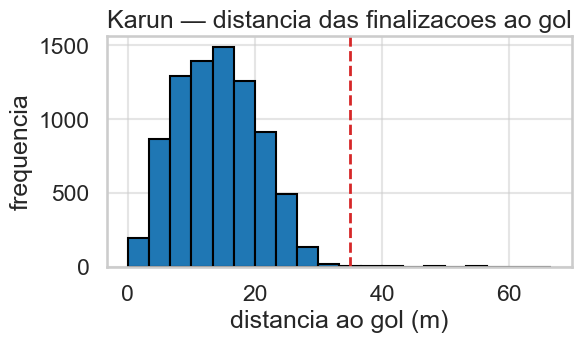

Acoes de treino usadas no Karun depois do filtro: 609,050


In [75]:

KARUN_GOAL_OUTLIER_DISTANCE = 35.0



def add_shot_distance_to_goal(actions, goal_x=PITCH_LENGTH, goal_y=PITCH_WIDTH / 2.0):
    df = actions.copy()
    df['distance_to_goal'] = np.sqrt((goal_x - df['x']) ** 2 + (goal_y - df['y']) ** 2)
    return df


xt_train = add_shot_distance_to_goal(
    actions_df.loc[actions_df['match_id'].isin(train_match_ids)].copy()
)
xt_test = add_shot_distance_to_goal(
    actions_df.loc[actions_df['match_id'].isin(test_match_ids)].copy()
)

long_goal_mask = (
    (xt_train['action_type'] == 'shot')
    & (xt_train['goal'] == 1)
    & (xt_train['distance_to_goal'] > KARUN_GOAL_OUTLIER_DISTANCE)
)

print(f'Limite de distancia para marcar gol como outlier: {KARUN_GOAL_OUTLIER_DISTANCE:.1f} m')
print(f'Gols de treino marcados como outlier: {int(long_goal_mask.sum())}')

display(
    xt_train.loc[
        long_goal_mask,
        ['match_id', 'game_event_id', 'x', 'y', 'distance_to_goal', 'raw_outcome']
    ].sort_values('distance_to_goal', ascending=False)
)

plt.figure(figsize=(6, 3))
plt.hist(
    xt_train.loc[xt_train['action_type'] == 'shot', 'distance_to_goal'].dropna(),
    bins=20,
    color='tab:blue',
    edgecolor='black',
)
plt.axvline(KARUN_GOAL_OUTLIER_DISTANCE, color='tab:red', linestyle='--', linewidth=2)
plt.title('Karun — distancia das finalizacoes ao gol')
plt.xlabel('distancia ao gol (m)')
plt.ylabel('frequencia')
plt.show()

karun_train_model_df = xt_train.loc[~long_goal_mask].copy()
print(f'Acoes de treino usadas no Karun depois do filtro: {len(karun_train_model_df):,}')


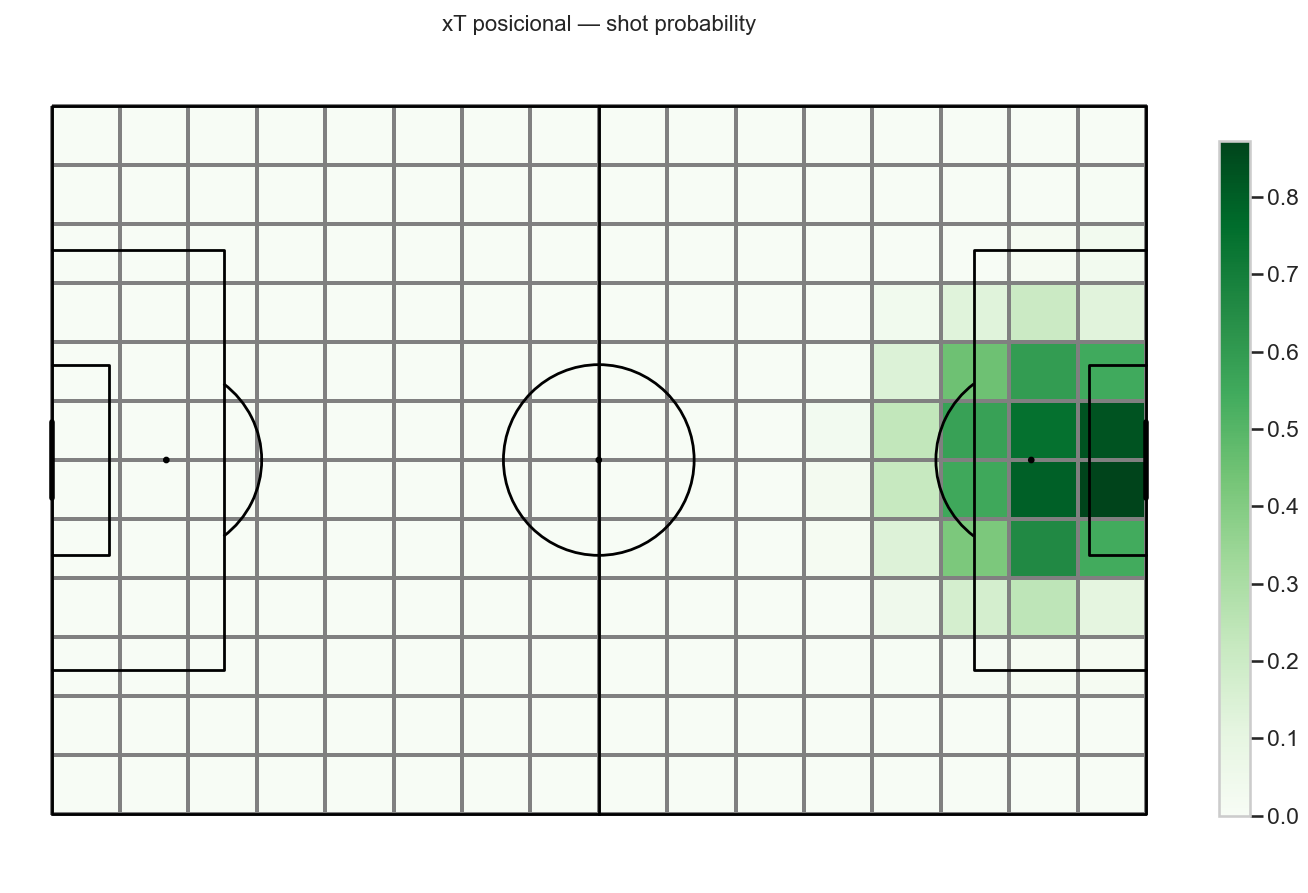

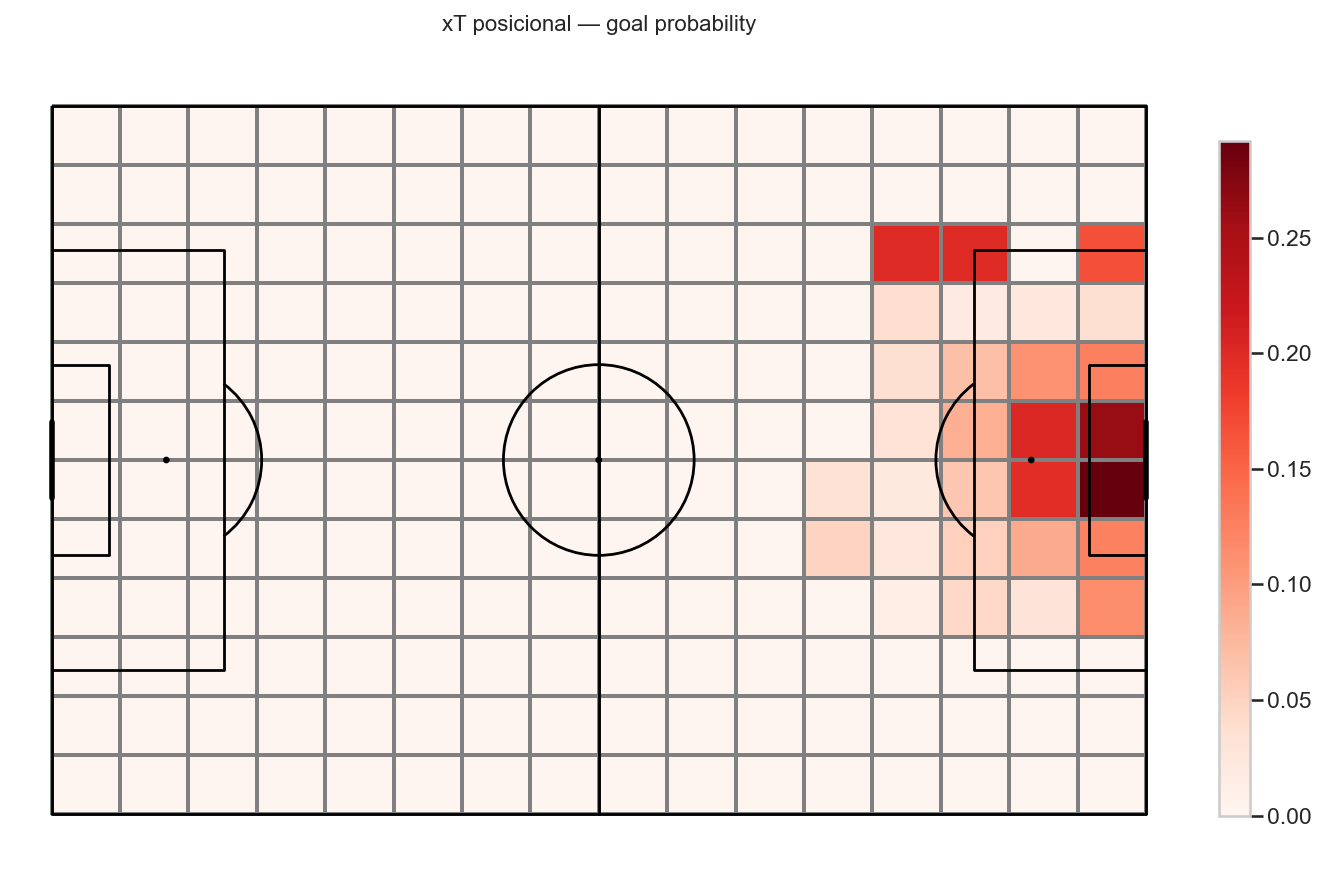

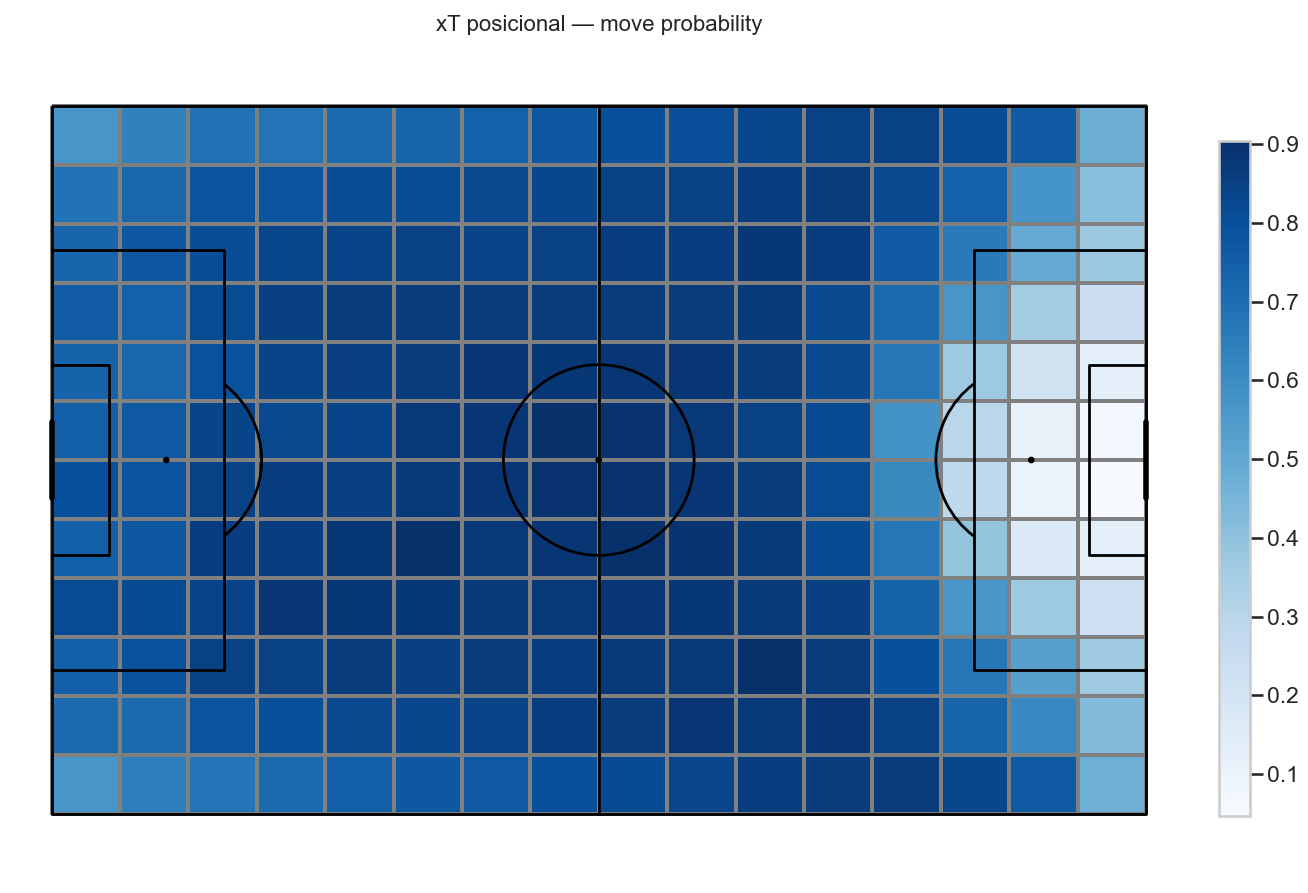

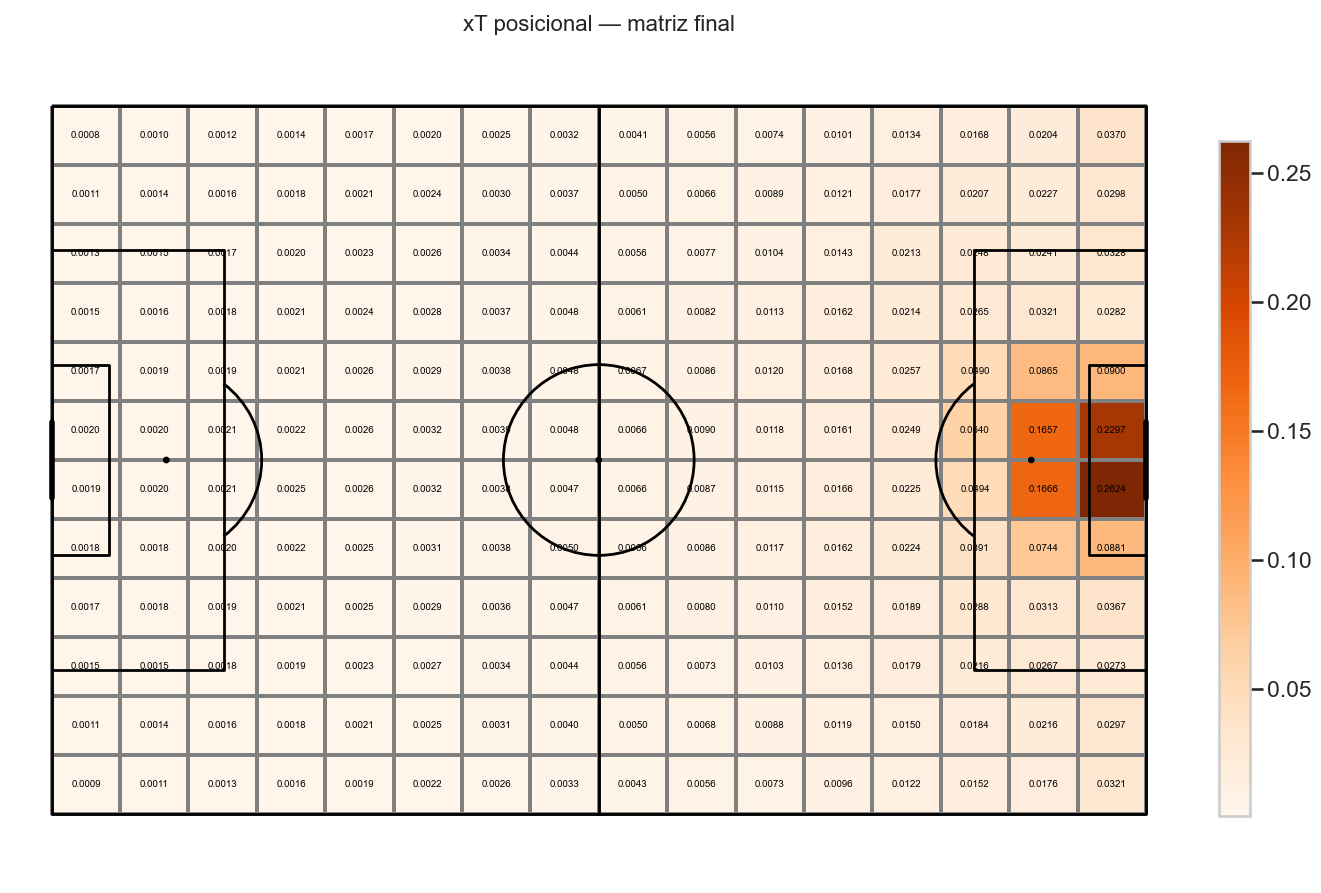

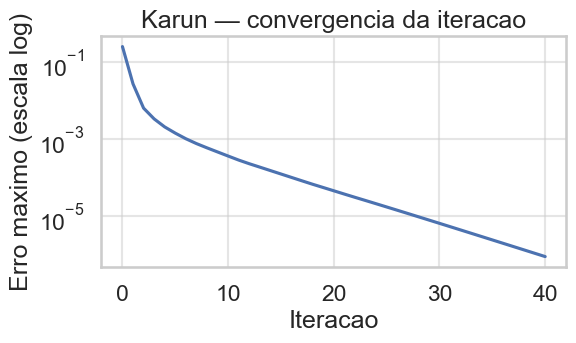

,model,target,n,positive_rate,brier_score,roc_auc
0,karun_xt,sequence_goal,152472,0.0174,0.0169,0.6560


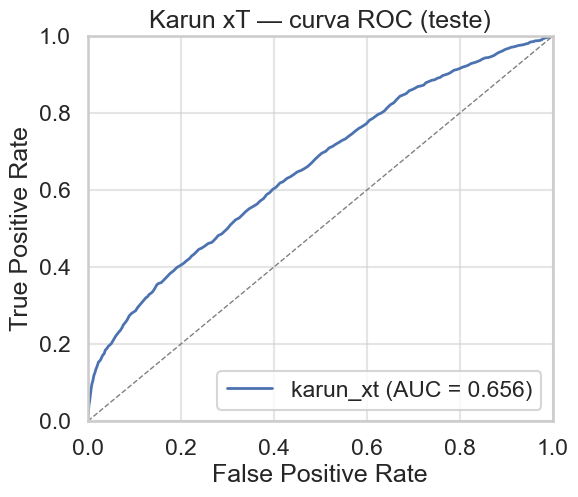

In [76]:

PITCH = Pitch(
    pitch_type='custom',
    pitch_length=PITCH_LENGTH,
    pitch_width=PITCH_WIDTH,
    line_color='black',
    line_zorder=2,
)
PITCH_TEMPLATE = PITCH.bin_statistic(
    np.array([0.5]),
    np.array([0.5]),
    statistic='count',
    bins=XT_BINS,
)



def plot_pitch_matrix(matrix, title, cmap='Oranges', annotate=False, fmt='{0:.2f}'):
    heatmap_data = deepcopy(PITCH_TEMPLATE)
    heatmap_data['statistic'] = matrix

    fig, ax = PITCH.grid(
        grid_height=0.88,
        title_height=0.06,
        axis=False,
        endnote_height=0.03,
        title_space=0,
        endnote_space=0,
    )
    pcm = PITCH.heatmap(heatmap_data, cmap=cmap, edgecolor='grey', ax=ax['pitch'])
    if annotate:
        PITCH.label_heatmap(
            heatmap_data,
            color='black',
            fontsize=7,
            ax=ax['pitch'],
            ha='center',
            va='center',
            str_format=fmt,
            zorder=3,
        )
    ax_cbar = fig.add_axes((1.0, 0.09, 0.025, 0.75))
    plt.colorbar(pcm, cax=ax_cbar)
    fig.suptitle(title, fontsize=16)
    plt.show()



def xy_to_bin_indices(x, y, bins=XT_BINS, pitch_length=PITCH_LENGTH, pitch_width=PITCH_WIDTH):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    n_x, n_y = bins
    x = min(max(float(x), 0.0), pitch_length - 1e-9)
    y = min(max(float(y), 0.0), pitch_width - 1e-9)
    bin_x = int(np.floor(x / pitch_length * n_x))
    bin_y = int(np.floor(y / pitch_width * n_y))
    return bin_x, bin_y



def add_xt_bins(actions, bins=XT_BINS):
    df = actions.copy()
    start_bins = df.apply(lambda row: xy_to_bin_indices(row['x'], row['y'], bins=bins), axis=1)
    end_bins = df.apply(lambda row: xy_to_bin_indices(row['x_end'], row['y_end'], bins=bins), axis=1)
    df['start_bin_x'] = [item[0] for item in start_bins]
    df['start_bin_y'] = [item[1] for item in start_bins]
    df['end_bin_x'] = [item[0] for item in end_bins]
    df['end_bin_y'] = [item[1] for item in end_bins]
    return df



def fit_positional_xt(actions, bins=XT_BINS, tol=XT_TOL, max_iters=XT_MAX_ITERS):
    n_x, n_y = bins
    df = add_xt_bins(actions, bins=bins)
    df = df.loc[
        df['action_type'].isin(XT_ACTION_TYPES)
        & df[['start_bin_x', 'start_bin_y']].notna().all(axis=1)
    ].copy()

    total_count = np.zeros((n_y, n_x), dtype=float)
    shot_count = np.zeros((n_y, n_x), dtype=float)
    goal_count = np.zeros((n_y, n_x), dtype=float)
    move_success_count = np.zeros((n_y, n_x), dtype=float)
    transition_count = np.zeros((n_y, n_x, n_y, n_x), dtype=float)

    for row in df.itertuples(index=False):
        sx = int(row.start_bin_x)
        sy = int(row.start_bin_y)
        total_count[sy, sx] += 1.0

        if row.action_type == 'shot':
            shot_count[sy, sx] += 1.0
            goal_count[sy, sx] += float(row.goal)
            continue

        if row.success == 1 and pd.notna(row.end_bin_x) and pd.notna(row.end_bin_y):
            ex = int(row.end_bin_x)
            ey = int(row.end_bin_y)
            move_success_count[sy, sx] += 1.0
            transition_count[sy, sx, ey, ex] += 1.0

    shot_probability = div_no_nan(shot_count, total_count)
    goal_probability = div_no_nan(goal_count, shot_count)
    move_probability = div_no_nan(move_success_count, total_count)

    transition_matrix = np.zeros_like(transition_count)
    for sy in range(n_y):
        for sx in range(n_x):
            if move_success_count[sy, sx] > 0:
                transition_matrix[sy, sx] = transition_count[sy, sx] / move_success_count[sy, sx]

    xT = np.zeros((n_y, n_x), dtype=float)
    convergence = []
    for _ in range(max_iters):
        expected_move_payoff = (transition_matrix * xT[None, None, :, :]).sum(axis=(2, 3))
        xT_new = shot_probability * goal_probability + move_probability * expected_move_payoff
        diff = np.abs(xT_new - xT).max()
        convergence.append(diff)
        xT = xT_new
        if diff < tol:
            break

    return {
        'grid_actions': df,
        'shot_probability': shot_probability,
        'goal_probability': goal_probability,
        'move_probability': move_probability,
        'transition_matrix': transition_matrix,
        'xT': xT,
        'convergence': convergence,
    }



def apply_positional_xt(actions, xt_model, bins=XT_BINS):
    df = add_xt_bins(actions, bins=bins)
    xT = xt_model['xT']

    def _lookup_start(row):
        if pd.isna(row['start_bin_x']) or pd.isna(row['start_bin_y']):
            return np.nan
        return xT[int(row['start_bin_y']), int(row['start_bin_x'])]

    def _lookup_end(row):
        if pd.isna(row['end_bin_x']) or pd.isna(row['end_bin_y']):
            return np.nan
        return xT[int(row['end_bin_y']), int(row['end_bin_x'])]

    df['xt_start'] = df.apply(_lookup_start, axis=1)
    df['xt_end'] = df.apply(_lookup_end, axis=1)
    move_mask = df['action_type'].isin(['pass', 'cross', 'carry']) & (df['success'] == 1)
    df['xt_added'] = np.where(move_mask, df['xt_end'] - df['xt_start'], np.nan)
    return df


karun_model = fit_positional_xt(karun_train_model_df)
xt_actions_df = apply_positional_xt(actions_df, karun_model)

plot_pitch_matrix(karun_model['shot_probability'], 'xT posicional — shot probability', cmap='Greens')
plot_pitch_matrix(karun_model['goal_probability'], 'xT posicional — goal probability', cmap='Reds')
plot_pitch_matrix(karun_model['move_probability'], 'xT posicional — move probability', cmap='Blues')
plot_pitch_matrix(karun_model['xT'], 'xT posicional — matriz final', cmap='Oranges', annotate=True, fmt='{0:.4f}')

plt.figure(figsize=(6, 3))
plt.plot(karun_model['convergence'])
plt.yscale('log')
plt.title('Karun — convergencia da iteracao')
plt.xlabel('Iteracao')
plt.ylabel('Erro maximo (escala log)')
plt.show()

karun_test_eval = xt_actions_df.loc[
    xt_actions_df['match_id'].isin(test_match_ids)
    & xt_actions_df['sequence_goal'].notna()
    & xt_actions_df['xt_start'].notna()
].copy()

karun_metrics, karun_curve = evaluate_binary_predictions(
    karun_test_eval['sequence_goal'],
    karun_test_eval['xt_start'],
    model_name='karun_xt',
    target_name='sequence_goal',
)
karun_metrics_df = pd.DataFrame([karun_metrics])
display(karun_metrics_df)
plot_roc_curves(
    [{'label': 'karun_xt', 'curve': karun_curve, 'auc': karun_metrics['roc_auc']}],
    'Karun xT — curva ROC (teste)',
)


In [77]:

value_adding_actions = xt_actions_df.loc[
    xt_actions_df['action_type'].isin(['pass', 'cross', 'carry'])
    & (xt_actions_df['success'] == 1)
    & xt_actions_df['xt_added'].notna()
].copy()

player_ranking = (
    value_adding_actions.groupby('player_id')['xt_added']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .head(15)
)
team_ranking = (
    value_adding_actions.groupby(['team_id', 'team_side'])['xt_added']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .head(10)
)

display(player_ranking)
display(team_ranking)


def plot_xt_story(value_actions, entity_kind='player', entity_id=None):
    if entity_kind not in {'player', 'team'}:
        raise ValueError("entity_kind deve ser 'player' ou 'team'.")
    if entity_id is None:
        raise ValueError('Defina entity_id para o exercicio.')

    key = 'player_id' if entity_kind == 'player' else 'team_id'
    subset = value_actions.loc[value_actions[key] == entity_id].copy()
    if subset.empty:
        raise ValueError('Nao encontrei acoes para esse identificador.')

    summary = (
        subset.groupby('action_type')['xt_added']
        .agg(['sum', 'mean', 'count'])
        .sort_values('sum', ascending=False)
    )
    display(summary)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    pitch = Pitch(
        pitch_type='custom',
        pitch_length=PITCH_LENGTH,
        pitch_width=PITCH_WIDTH,
        line_color='black',
    )

    pitch.draw(ax=axes[0])
    pitch.scatter(subset['x'], subset['y'], s=20, alpha=0.6, ax=axes[0])
    axes[0].set_title(f'Origens das acoes ({entity_kind}={entity_id})')

    pitch.draw(ax=axes[1])
    pitch.scatter(subset['x_end'], subset['y_end'], s=20, alpha=0.6, ax=axes[1])
    axes[1].set_title('Destinos das acoes de valor')

    summary['sum'].plot(kind='bar', ax=axes[2], color='tab:orange')
    axes[2].set_title('xT_added por tipo de acao')
    axes[2].set_ylabel('xT_added total')
    plt.tight_layout()
    plt.show()


ENTITY_KIND = 'player'  # troque para 'team' se quiser
ENTITY_ID = None        # ex.: 4793 ou 166

# Exemplo de uso:
# plot_xt_story(value_adding_actions, entity_kind=ENTITY_KIND, entity_id=ENTITY_ID)


,sum,mean,count
player_id,,,
133.0000,8.9171,0.0050,1781
"8,074.0000",8.6059,0.0060,1430
"12,779.0000",8.6028,0.0072,1201
"5,074.0000",7.4396,0.0074,1002
42.0000,7.0186,0.0047,1497
22.0000,6.7912,0.0072,940
"3,112.0000",6.4647,0.0106,608
596.0000,6.4590,0.0049,1327
"2,003.0000",6.4355,0.0064,1002


,,sum,mean,count
team_id,team_side,,,
10.0000,away,22.0155,0.0024,9172
119.0000,home,21.4391,0.0028,7577
13.0000,home,21.2766,0.0027,7853
2.0000,home,21.0626,0.0023,9275
4.0000,home,20.8635,0.0024,8537
1.0000,home,20.2608,0.0030,6804
3.0000,home,20.1494,0.0023,8676
10.0000,home,19.1148,0.0020,9795
54.0000,away,18.5500,0.0022,8492


In [78]:
# read players.json
import json
players_path = EVENTS_DIR / 'players.json'
with open(players_path, 'r') as f:
    players_data = json.load(f)

# to pandas
players_df = pd.DataFrame(players_data)
players_df['player_id'] = players_df['id'].astype(float)

player_ranking = (
    value_adding_actions.groupby('player_id')['xt_added']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .head(15)
).merge(players_df[['player_id', 'nickname']].drop_duplicates(), on='player_id', how='left')
player_ranking

,player_id,sum,mean,count,nickname
0,133.0000,8.9171,0.0050,1781,Bruno Fernandes
1,"8,074.0000",8.6059,0.0060,1430,Pedro Porro
2,"12,779.0000",8.6028,0.0072,1201,Mikkel Damsgaard
3,"5,074.0000",7.4396,0.0074,1002,Bryan Mbeumo
4,42.0000,7.0186,0.0047,1497,Trent Alexander-Arnold
5,22.0000,6.7912,0.0072,940,Kevin De Bruyne
6,"3,112.0000",6.4647,0.0106,608,Anthony Elanga
7,596.0000,6.4590,0.0049,1327,Cole Palmer
8,"2,003.0000",6.4355,0.0064,1002,Leif Davis
9,"4,850.0000",6.3487,0.0070,910,Matheus Cunha


,match_id,period,start_time,game_event_id,team_id,player_id,action_type,x,y,x_end,y_end,success,goal,end_was_copied_from_start,score_next_10_actions,concede_next_10_actions
0,31995,1,73.5740,24426842,54.0000,134.0000,pass,50.8400,33.8900,43.1510,33.9450,1.0000,0,0,0,0
1,31995,1,74.3410,24426890,54.0000,"12,664.0000",interception,44.5400,33.5300,44.5400,33.5300,NaN,0,1,0,0
2,31995,1,74.3410,24426890,54.0000,"12,664.0000",pass,42.4200,31.3200,27.5670,27.5560,1.0000,0,0,0,0
3,31995,1,76.9440,24426892,54.0000,257.0000,interception,28.0500,27.1700,28.0500,27.1700,NaN,0,1,0,0
4,31995,1,76.9440,24426892,54.0000,257.0000,pass,31.3400,11.5800,62.3120,1.6840,1.0000,0,0,0,0
5,31995,1,82.4490,24426893,54.0000,250.0000,touch_control,64.4500,6.3100,64.4500,6.3100,NaN,0,1,0,0
6,31995,1,84.0840,24426895,12.0000,250.0000,challenge,43.5400,57.5900,43.5400,57.5900,NaN,0,1,0,0
7,31995,1,84.0840,24426895,12.0000,"13,699.0000",pass,39.2200,66.7700,46.2200,67.0660,1.0000,0,0,0,0
8,31995,1,87.0540,24426897,12.0000,136.0000,interception,46.0000,66.8300,46.0000,66.8300,NaN,0,1,0,0
9,31995,1,87.0540,24426897,12.0000,136.0000,pass,48.1600,66.2000,52.4300,63.1670,0.0000,0,0,0,0


,action_type,n
0,pass,356552
1,interception,257558
2,challenge,66681
3,clearance,16802
4,carry,15673
5,rebound,15584
6,cross,15451
7,shot,10142
8,touch_control,7627
9,foul,255


Linhas com destino copiado do inicio: 49.28%


,model,target,n,positive_rate,brier_score,roc_auc
0,baseline_concede_next_10_actions,concede_next_10_actions,153270,0.0034,0.1930,0.7384
1,baseline_score_next_10_actions,score_next_10_actions,153270,0.0127,0.1960,0.7657


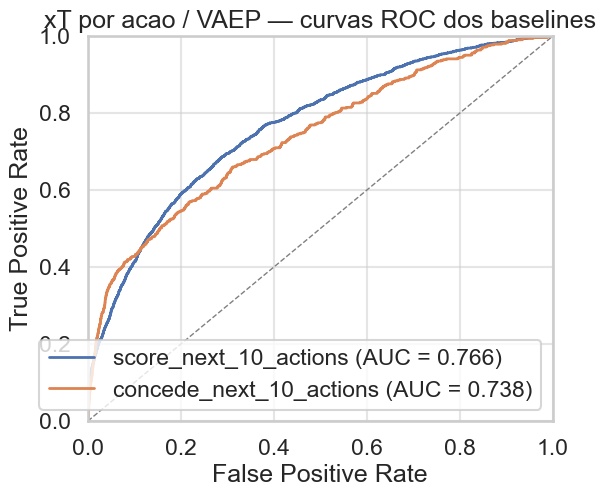

In [79]:

def build_action_features_and_targets(actions, horizon=10):
    df = actions.copy()
    keep_cols = [
        'match_id',
        'period',
        'start_time',
        'game_event_id',
        'team_id',
        'player_id',
        'action_type',
        'x',
        'y',
        'x_end',
        'y_end',
        'success',
        'goal',
    ]
    df = df[keep_cols].sort_values(['match_id', 'period', 'start_time', 'game_event_id']).reset_index(drop=True)

    missing_end_mask = df['x_end'].isna() | df['y_end'].isna()
    df.loc[df['x_end'].isna(), 'x_end'] = df.loc[df['x_end'].isna(), 'x']
    df.loc[df['y_end'].isna(), 'y_end'] = df.loc[df['y_end'].isna(), 'y']
    df['end_was_copied_from_start'] = missing_end_mask.astype(int)

    df['score_next_10_actions'] = 0
    df['concede_next_10_actions'] = 0

    for match_id, idx in df.groupby('match_id').groups.items():
        local = df.loc[idx].reset_index()
        teams = local['team_id'].to_numpy()
        goals = local['goal'].fillna(0).astype(int).to_numpy()
        score_target = np.zeros(len(local), dtype=int)
        concede_target = np.zeros(len(local), dtype=int)

        for i in range(len(local)):
            j = min(len(local), i + horizon)
            future_goals = goals[i:j].astype(bool)
            future_teams = teams[i:j]
            if future_goals.any():
                scoring_teams = future_teams[future_goals]
                score_target[i] = int(np.any(scoring_teams == teams[i]))
                concede_target[i] = int(np.any(scoring_teams != teams[i]))

        df.loc[local['index'], 'score_next_10_actions'] = score_target
        df.loc[local['index'], 'concede_next_10_actions'] = concede_target

    return df



def fit_action_baseline(train_df, test_df, target_col):
    feature_cols = ['x', 'y', 'x_end', 'y_end', 'action_type', 'success']
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].astype(int).copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].astype(int).copy()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                ]),
                ['x', 'y', 'x_end', 'y_end'],
            ),
            (
                'cat',
                OneHotEncoder(handle_unknown='ignore'),
                ['action_type'],
            ),
            (
                'succ',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value=-1.0)),
                ]),
                ['success'],
            ),
        ]
    )

    if y_train.nunique() < 2:
        model = Pipeline(
            steps=[
                ('prep', preprocessor),
                ('clf', DummyClassifier(strategy='prior')),
            ]
        )
    else:
        model = Pipeline(
            steps=[
                ('prep', preprocessor),
                ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
            ]
        )

    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)
    if proba.shape[1] == 1:
        positive_class = int(model.named_steps['clf'].classes_[0])
        y_prob = np.full(len(X_test), float(positive_class))
    else:
        class_to_idx = {int(cls): idx for idx, cls in enumerate(model.named_steps['clf'].classes_)}
        y_prob = proba[:, class_to_idx[1]]

    metrics, curve = evaluate_binary_predictions(
        y_test,
        y_prob,
        model_name=f'baseline_{target_col}',
        target_name=target_col,
    )
    return model, y_prob, metrics, curve


action_features_df = build_action_features_and_targets(actions_df, horizon=HORIZON_ACTIONS)
display(action_features_df.head(10))

display(
    action_features_df['action_type']
    .value_counts(dropna=False)
    .rename_axis('action_type')
    .reset_index(name='n')
)
print(f'Linhas com destino copiado do inicio: {action_features_df["end_was_copied_from_start"].mean():.2%}')

vaep_train = action_features_df.loc[action_features_df['match_id'].isin(train_match_ids)].copy()
vaep_test = action_features_df.loc[action_features_df['match_id'].isin(test_match_ids)].copy()

score_model, score_prob, score_metrics, score_curve = fit_action_baseline(
    vaep_train,
    vaep_test,
    target_col='score_next_10_actions',
)
concede_model, concede_prob, concede_metrics, concede_curve = fit_action_baseline(
    vaep_train,
    vaep_test,
    target_col='concede_next_10_actions',
)

vaep_metrics_df = pd.DataFrame([score_metrics, concede_metrics]).sort_values(['target', 'brier_score']).reset_index(drop=True)
display(vaep_metrics_df)

plot_roc_curves(
    [
        {'label': 'score_next_10_actions', 'curve': score_curve, 'auc': score_metrics['roc_auc']},
        {'label': 'concede_next_10_actions', 'curve': concede_curve, 'auc': concede_metrics['roc_auc']},
    ],
    'xT por acao / VAEP — curvas ROC dos baselines',
)


In [80]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import ast

def prepare_shots_data_from_csv(df):
    # 1. Filtra chutes
    shots = df[df['possession_events_possession_event_type'] == 'SH'].copy()
    
    # 2. Nova extração lendo a chave do dicionário ('x' e 'y')
    def parse_coordinate(val, key):
        try:
            if pd.isna(val):
                return np.nan
            if isinstance(val, str):
                val = ast.literal_eval(val) # Transforma string em lista de dicionário
            
            # Pega o primeiro item da lista e acessa a chave pedida ('x' ou 'y')
            if isinstance(val, list) and len(val) > 0:
                return float(val[0][key])
            elif isinstance(val, dict):
                return float(val[key])
            return np.nan
        except:
            return np.nan

    shots['X'] = shots['ball'].apply(lambda b: parse_coordinate(b, 'x'))
    shots['Y'] = shots['ball'].apply(lambda b: parse_coordinate(b, 'y'))
    
    # Remove chutes sem coordenadas
    shots = shots.dropna(subset=['X', 'Y']).copy()
    
    # 3. Geometria do Chute (Campo zero-centered)
    # Assumindo comprimento 105m (gols em X = 52.5 e X = -52.5) e largura 68m (centro Y = 0)
    # abs(X) faz com que a gente sempre calcule a distância para o gol do ataque
    shots['X_dist'] = 52.5 - abs(shots['X'])  
    shots['C'] = abs(shots['Y']) # Como o centro é 0, a distância ao centro é o próprio módulo de Y
    
    # Distância Euclidiana
    shots['Distance'] = np.sqrt(shots['X_dist']**2 + shots['C']**2)
    
    # Ângulo (Proteção contra Divisão por Zero)
    denominador = (shots['X_dist']**2 + shots['C']**2 - (7.32 / 2)**2)
    denominador = np.where(denominador == 0, 1e-6, denominador) 
    
    angle = np.arctan(7.32 * shots['X_dist'] / denominador)
    shots['Angle'] = np.where(angle > 0, angle, angle + np.pi)
    
    # 4. Definir a variável Alvo (Gol = 1)
    shots['Goal'] = shots['possession_events_shot_outcome_type'].apply(
        lambda x: 1 if str(x).strip().upper() in ['GOAL', 'G'] else 0
    )
    
    return shots.dropna(subset=['Distance', 'Angle', 'Goal'])

# ==========================================
# EXECUÇÃO E TREINAMENTO FINAL
# ==========================================

print("Preparando dados matemáticos dos chutes...")
shots_data_treino = prepare_shots_data_from_csv(all_value_events_df)

print(f"Total de chutes processados para treino: {len(shots_data_treino)}")
print(f"Total de gols encontrados no dataset: {shots_data_treino['Goal'].sum()}")

if shots_data_treino['Goal'].sum() > 0:
    print("\nTreinando modelo de xG (Regressão Logística)...")
    xg_model = smf.glm(formula="Goal ~ Distance + Angle", 
                       data=shots_data_treino, 
                       family=sm.families.Binomial()).fit()

    print("\n--- Resumo do Modelo xG Treinado ---")
    print(xg_model.summary().tables[1])
else:
    print("[ERRO] Os chutes foram lidos, mas 0 gols foram encontrados. Verifique a grafia de 'GOAL' no dataset.")

Preparando dados matemáticos dos chutes...
Total de chutes processados para treino: 10121
Total de gols encontrados no dataset: 1201

Treinando modelo de xG (Regressão Logística)...

--- Resumo do Modelo xG Treinado ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7690      0.141     -5.446      0.000      -1.046      -0.492
Distance      -0.1225      0.008    -14.737      0.000      -0.139      -0.106
Angle          0.3890      0.081      4.809      0.000       0.230       0.548


In [81]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

def generate_match_xg_report(game_id, events_df, subs_df, model, path_players=None):
    """
    Gera um relatório completo de xG e placar real para uma partida específica,
    detalhando os eventos (gols e substituições) na linha do tempo.
    Adaptado para funcionar com o novo dataframe de substituições limpo.
    """
    # 1. Carregar mapeamento dos jogadores (ID -> Nome)
    player_map = {}
    if path_players and Path(path_players).exists():
        with open(path_players, 'r', encoding='utf-8') as f:
            players_list = json.load(f)
            player_map = {int(p['id']): p.get('nickname') or f"{p['firstName']} {p['lastName']}" for p in players_list}

    def get_player_name(pid_raw):
        try:
            pid = int(float(pid_raw)) if pd.notna(pid_raw) else -1
            return player_map.get(pid, f"ID {pid_raw}")
        except:
            return f"ID {pid_raw}"

    # 2. Filtrar dados do jogo (Tolerante a diferenças de nome das colunas)
    col_events = 'match_id' if 'match_id' in events_df.columns else 'game_id'
    col_subs = 'match_id' if 'match_id' in subs_df.columns else 'game_id'
    
    match_events = events_df[events_df[col_events] == game_id].copy()
    match_subs = subs_df[subs_df[col_subs] == game_id].copy()
    
    if match_events.empty:
        print(f"❌ Nenhum evento encontrado para o ID: {game_id}")
        return
        
    # Limpa duplicatas de substituições buscando pelas colunas novas ou antigas
    if not match_subs.empty:
        c_off = 'player_off_id' if 'player_off_id' in match_subs.columns else 'game_events_player_off_id'
        c_on = 'player_on_id' if 'player_on_id' in match_subs.columns else 'game_events_player_on_id'
        match_subs = match_subs.drop_duplicates(subset=['start_time', c_off, c_on])

    # --- DESCOBRIR QUEM É O MANDANTE ---
    id_mandante = None
    if 'game_events_team_id' in match_events.columns and 'game_events_home_team' in match_events.columns:
        home_events = match_events[match_events['game_events_home_team'] == True]
        if not home_events.empty:
            id_mandante = home_events['game_events_team_id'].iloc[0]

    # 3. Extrair coordenadas e calcular xG de todos os chutes
    match_shots = prepare_shots_data_from_csv(match_events)
    if not match_shots.empty:
        match_shots['xG'] = model.predict(match_shots)
        
        # Mapeia quem é quem nos chutes
        if 'game_events_home_team' in match_shots.columns:
            match_shots['Team_Side'] = match_shots['game_events_home_team'].apply(
                lambda x: 'Mandante' if x == True else 'Visitante'
            )
        else:
            match_shots['Team_Side'] = match_shots['game_events_team_id'].apply(
                lambda tid: 'Mandante' if tid == id_mandante else 'Visitante'
            )
    else:
        match_shots = pd.DataFrame(columns=['start_time', 'Team_Side', 'xG', 'Goal'])

    # 4. Construir Linha do Tempo Unificada (Gols + Substituições)
    milestones = []
    
    # 4.1 Identificar os Gols
    goals_df = match_events[
        (match_events['possession_events_possession_event_type'] == 'SH') &
        (match_events['possession_events_shot_outcome_type'].astype(str).str.strip().str.upper().isin(['GOAL', 'G']))
    ]
    for _, goal in goals_df.iterrows():
        is_home = goal.get('game_events_home_team')
        tid = goal.get('game_events_team_id')
        side = 'Mandante' if is_home == True or tid == id_mandante else 'Visitante'
        
        milestones.append({
            'time': goal['start_time'],
            'type': 'GOAL',
            'team_str': side,
            'player_id': goal['game_events_player_id']
        })
        
    # 4.2 Identificar as Substituições (usando a base limpa)
    for _, sub in match_subs.iterrows():
        tid = sub.get('team_id')
        
        # Define o lado baseado no team_id limpo
        if pd.notna(tid) and id_mandante is not None:
            side = 'Mandante' if tid == id_mandante else 'Visitante'
        else:
            side = 'Mandante' if sub.get('game_events_home_team') == True else 'Visitante'
            
        milestones.append({
            'time': sub['start_time'],
            'type': 'SUB',
            'team_str': side,
            'player_off': sub.get('player_off_id', sub.get('game_events_player_off_id')),
            'player_on': sub.get('player_on_id', sub.get('game_events_player_on_id')),
            'name_off': sub.get('player_off_name'),
            'name_on': sub.get('player_on_name'),
            'sub_type': sub.get('game_events_player_off_type', 'Tática')
        })
        
    # 5. LINHA DO TEMPO CRONOLÓGICA
    t_start = 0
    t_end = match_events['start_time'].max() if not match_events.empty else 5400
    
    unique_times = sorted(list(set(m['time'] for m in milestones)))
    timeline = sorted(list(set([t_start] + unique_times + [t_end])))
    
    accum_home_xg, accum_away_xg = 0.0, 0.0
    score_home, score_away = 0, 0

    print("=" * 70)
    print(f"📊 RELATÓRIO ESTATÍSTICO DE xG E PLACAR - PARTIDA ID: {game_id}")
    print("=" * 70)
    print("\n⏳ ANÁLISE CRONOLÓGICA: DELTAS, GOLS E SUBSTITUIÇÕES")
    print("-" * 70)

    def format_time(seconds):
        if pd.isna(seconds): return "00:00"
        m, s = divmod(int(seconds), 60)
        return f"{m:02d}:{s:02d}"

    for i in range(len(timeline) - 1):
        t_low = timeline[i]
        t_high = timeline[i+1]
        
        if t_high > t_low:
            interval_shots = match_shots[(match_shots['start_time'] >= t_low) & (match_shots['start_time'] < t_high)]
            delta_home_xg = interval_shots[interval_shots['Team_Side'] == 'Mandante']['xG'].sum() if not interval_shots.empty else 0
            delta_away_xg = interval_shots[interval_shots['Team_Side'] == 'Visitante']['xG'].sum() if not interval_shots.empty else 0
            
            accum_home_xg += delta_home_xg
            accum_away_xg += delta_away_xg

            print(f"Intervalo: {format_time(t_low)} até {format_time(t_high)}")
            print(f"  ↳ Delta xG Mandante : +{delta_home_xg:.3f} (Total acumulado: {accum_home_xg:.2f})")
            print(f"  ↳ Delta xG Visitante: +{delta_away_xg:.3f} (Total acumulado: {accum_away_xg:.2f})")
        
        events_now = [m for m in milestones if m['time'] == t_high]
        
        goals_now = [e for e in events_now if e['type'] == 'GOAL']
        for g in goals_now:
            if g['team_str'] == 'Mandante':
                score_home += 1
            else:
                score_away += 1
                
            scorer = get_player_name(g['player_id'])
            
            print(f"\n⚽ [GOL!] aos {format_time(t_high)} - {scorer} ({g['team_str']})")
            print(f"  PLACAR ATUAL: Mandante {score_home} x {score_away} Visitante")
            print("-" * 70)
            
        subs_now = [e for e in events_now if e['type'] == 'SUB']
        if subs_now:
            print(f"\n🔄 [SUBSTITUIÇÃO] aos {format_time(t_high)}")
            print(f"  Placar Real Atual: Mandante {score_home} x {score_away} Visitante")
            print(f"  Placar xG Atual  : Mandante {accum_home_xg:.2f} x {accum_away_xg:.2f} Visitante")
            
            for sub in subs_now:
                # Usa os nomes limpos direto do DataFrame se existirem
                p_out = sub['name_off'] if pd.notna(sub.get('name_off')) else get_player_name(sub['player_off'])
                p_in = sub['name_on'] if pd.notna(sub.get('name_on')) else get_player_name(sub['player_on'])
                p_type = sub['sub_type'] if pd.notna(sub.get('sub_type')) else 'Tática'
                
                print(f"  • Equipe: {sub['team_str']}")
                print(f"    🔻 Saiu: {p_out} ({p_type})")
                print(f"    🔺 Entrou: {p_in}")
            print("-" * 70)
            
    print("🏁 Fim da partida.")
    print("=" * 70)
    print("RESUMO FINAL DA PARTIDA:")
    print(f"Placar Real: Mandante {score_home} x {score_away} Visitante")
    print(f"Placar xG  : Mandante {accum_home_xg:.2f} x {accum_away_xg:.2f} Visitante")
    print("=" * 70)

In [82]:
# ==============================================================================
# EXEMPLO DE EXECUÇÃO DO RELATÓRIO
# ==============================================================================
# Caminho do arquivo de jogadores no seu Drive Desktop local
CAMINHO_PLAYERS = Path('dados/') / 'players.json'

# Escolha qualquer ID de jogo presente no seu dataset para testar o relatório
id_jogo_teste = 32017

# Chamar a função para imprimir a análise na tela
generate_match_xg_report(
    game_id=id_jogo_teste,
    events_df=all_value_events_df,
    subs_df=substitutions_df,
    model=xg_model,
    path_players=CAMINHO_PLAYERS
)

📊 RELATÓRIO ESTATÍSTICO DE xG E PLACAR - PARTIDA ID: 32017

⏳ ANÁLISE CRONOLÓGICA: DELTAS, GOLS E SUBSTITUIÇÕES
----------------------------------------------------------------------
Intervalo: 00:00 até 53:15
  ↳ Delta xG Mandante : +0.779 (Total acumulado: 0.78)
  ↳ Delta xG Visitante: +0.352 (Total acumulado: 0.35)

⚽ [GOL!] aos 53:15 - Michael Keane (Mandante)
  PLACAR ATUAL: Mandante 1 x 0 Visitante
----------------------------------------------------------------------
Intervalo: 53:15 até 59:26
  ↳ Delta xG Mandante : +0.310 (Total acumulado: 1.09)
  ↳ Delta xG Visitante: +0.000 (Total acumulado: 0.35)

⚽ [GOL!] aos 59:26 - Dominic Calvert-Lewin (Mandante)
  PLACAR ATUAL: Mandante 2 x 0 Visitante
----------------------------------------------------------------------
Intervalo: 59:26 até 68:11
  ↳ Delta xG Mandante : +0.245 (Total acumulado: 1.33)
  ↳ Delta xG Visitante: +0.000 (Total acumulado: 0.35)

🔄 [SUBSTITUIÇÃO] aos 68:11
  Placar Real Atual: Mandante 2 x 0 Visitante
  Plac

In [83]:
#TREINAMENTO xT
import json

def build_and_apply_xt(actions_df, train_match_ids):
    """
    Treina o modelo de xT Posicional usando os jogos de treino e
    aplica a métrica (xt_added) a todas as ações da temporada.
    """
    print("Treinando modelo xT Posicional (Grade 16x12)...")
    # Filtra apenas os jogos de treino usando a lista de IDs
    df_train = actions_df[actions_df['match_id'].isin(train_match_ids)].copy()
    
    # Chama a função do notebook original para ajustar o modelo
    xt_model = fit_positional_xt(df_train)
    
    print("Aplicando xT calculado em todas as ações...")
    # Aplica o modelo criado ao dataset geral
    actions_xt_df = apply_positional_xt(actions_df, xt_model)
    
    # Preenche NaNs com 0 para facilitar as somas no relatório
    actions_xt_df['xt_added'] = actions_xt_df['xt_added'].fillna(0.0)
    
    return xt_model, actions_xt_df

In [104]:
def build_and_apply_vaep(actions_df, train_match_ids):
    """
    Cria as features de histórico, treina os baselines de probabilidade 
    e calcula o Valor Ofensivo, Defensivo e o VAEP Total de cada ação.
    """
    print("Extraindo histórico (features) de ações para o VAEP...")
    features_df = build_action_features_and_targets(actions_df, horizon=HORIZON_ACTIONS)
    
    df_train = features_df[features_df['match_id'].isin(train_match_ids)].copy()
    
    print("Ajustando modelos de Score e Concede...")
    # Usamos o fit_action_baseline aplicando a previsão no features_df completo
    score_model, score_prob, _, _ = fit_action_baseline(df_train, features_df, target_col='score_next_10_actions')
    concede_model, concede_prob, _, _ = fit_action_baseline(df_train, features_df, target_col='concede_next_10_actions')
    
    features_df['score_prob'] = score_prob
    features_df['concede_prob'] = concede_prob
    
    print("Calculando Valor Ofensivo e Defensivo...")
    # Ordena cronologicamente para garantir a sequência exata de eventos no jogo
    features_df = features_df.sort_values(['match_id', 'period', 'start_time', 'game_event_id'])
    
    # 1. Agrupar apenas por partida e tempo, recuperando a ação IMEDIATAMENTE anterior
    prev_team_id = features_df.groupby(['match_id', 'period'])['team_id'].shift(1)
    prev_score_raw = features_df.groupby(['match_id', 'period'])['score_prob'].shift(1).fillna(0.0)
    prev_concede_raw = features_df.groupby(['match_id', 'period'])['concede_prob'].shift(1).fillna(0.0)
    
    # 2. Identificar se houve mudança de posse (adversário fez a ação anterior)
    is_same_team = (features_df['team_id'] == prev_team_id)
    
    # 3. Se for o mesmo time, usamos as probs anteriores como vieram.
    #    Se mudou de time, a probabilidade de marcar do adversário vira a NOSSA de sofrer, e vice-versa.
    import numpy as np
    features_df['prev_score_prob'] = np.where(is_same_team, prev_score_raw, prev_concede_raw)
    features_df['prev_concede_prob'] = np.where(is_same_team, prev_concede_raw, prev_score_raw)
    
    # Preenchimento de NaN (apenas nas primeiras ações de cada tempo da partida)
    features_df['prev_score_prob'] = features_df['prev_score_prob'].fillna(0.0)
    features_df['prev_concede_prob'] = features_df['prev_concede_prob'].fillna(0.0)
    
    # Aplicação das fórmulas didáticas
    features_df['offensive_value'] = features_df['score_prob'] - features_df['prev_score_prob']
    features_df['defensive_value'] = features_df['prev_concede_prob'] - features_df['concede_prob']
    features_df['vaep_value'] = features_df['offensive_value'] + features_df['defensive_value']
    
    # Remove valores nulos caso ocorram no início da posse
    features_df['vaep_value'] = features_df['vaep_value'].fillna(0.0)
    
    return {'score': score_model, 'concede': concede_model}, features_df

In [105]:
def generate_xt_vaep_report(game_id, combined_actions_df, subs_df, path_players=None):
    # 1. Carregar jogadores
    player_map = {}
    if path_players and Path(path_players).exists():
        with open(path_players, 'r', encoding='utf-8') as f:
            players_list = json.load(f)
            player_map = {int(p['id']): p.get('nickname') or f"{p['firstName']} {p['lastName']}" for p in players_list}

    # 2. Filtrar Jogo
    df_actions = combined_actions_df[combined_actions_df['match_id'] == game_id].copy().reset_index(drop=True)
    df_subs = subs_df[subs_df['match_id'] == game_id].copy().reset_index(drop=True)

    if df_actions.empty:
        print(f"❌ Nenhuma ação encontrada para a partida ID: {game_id}")
        return

    # --- IDENTIFICAÇÃO DE TIME BLINDADA ---
    # Se não temos 'game_events_home_team', assumimos que o primeiro ID que aparece 
    # nas ações do mandante é o dono da casa, ou usamos uma lógica de contagem.
    # Vamos assumir que o time que tem mais ações no jogo é o mandante (ou você pode ajustar manualmente)
    contagem_times = df_actions['team_id'].value_counts()
    id_mandante = contagem_times.index[0] # Time com mais ações é o "dono da casa" provável
    
    def rotular_time(tid):
        return 'Mandante' if tid == id_mandante else 'Visitante'

    df_actions['Team_Side_Str'] = df_actions['team_id'].apply(rotular_time)
    df_subs['Team_Side_Str'] = df_subs['team_id'].apply(rotular_time)

    # Totais
    total_home_xt = df_actions[df_actions['Team_Side_Str'] == 'Mandante']['xt_added'].sum()
    total_away_xt = df_actions[df_actions['Team_Side_Str'] == 'Visitante']['xt_added'].sum()
    total_home_vaep = df_actions[df_actions['Team_Side_Str'] == 'Mandante']['vaep_value'].sum()
    total_away_vaep = df_actions[df_actions['Team_Side_Str'] == 'Visitante']['vaep_value'].sum()

    print("=" * 80)
    print(f"📊 RELATÓRIO DE AMEAÇA (xT) E VALOR (VAEP) - PARTIDA ID: {game_id}")
    print(f"🏠 Mandante (Time ID {id_mandante}) | 🚀 Visitante")
    print("=" * 80)
    print(f"🏠 Mandante  -> Total xT: {total_home_xt:.3f} | Total VAEP: {total_home_vaep:.3f}")
    print(f"🚀 Visitante -> Total xT: {total_away_xt:.3f} | Total VAEP: {total_away_vaep:.3f}")
    print("=" * 80)

    # 3. Unificar Linha do Tempo
    milestones = []
    
    # Gols
    for _, goal in df_actions[df_actions['goal'] == 1].iterrows():
        milestones.append({'time': goal['start_time'], 'type': 'GOAL', 'team_str': goal['Team_Side_Str'], 'player_id': goal['player_id']})

    # Subs
    for _, sub in df_subs.iterrows():
        milestones.append({
            'time': sub['start_time'], 'type': 'SUB',
            'team_str': sub['Team_Side_Str'],
            'name_off': sub['player_off_name'],
            'name_on': sub['player_on_name']
        })

    timeline = sorted(list(set([0] + [m['time'] for m in milestones] + [df_actions['start_time'].max()])))

    # 4. Loop de Análise
    print("\n⏳ ANÁLISE CRONOLÓGICA")
    accum_home_xt, accum_away_xt = 0.0, 0.0
    accum_home_vaep, accum_away_vaep = 0.0, 0.0
    
    for i in range(len(timeline) - 1):
        t_low, t_high = timeline[i], timeline[i+1]
        if t_high <= t_low: continue
            
        interval = df_actions[(df_actions['start_time'] >= t_low) & (df_actions['start_time'] < t_high)]
        accum_home_xt += interval[interval['Team_Side_Str'] == 'Mandante']['xt_added'].sum()
        accum_away_xt += interval[interval['Team_Side_Str'] == 'Visitante']['xt_added'].sum()
        accum_home_vaep += interval[interval['Team_Side_Str'] == 'Mandante']['vaep_value'].sum()
        accum_away_vaep += interval[interval['Team_Side_Str'] == 'Visitante']['vaep_value'].sum()

        for m in [x for x in milestones if x['time'] == t_high]:
            if m['type'] == 'SUB':
                print(f"\n🔄 [{m['team_str']}] aos {(t_high/60):.1f}' - Entrou: {m['name_on']} | Saiu: {m['name_off']}")
                print(f"   xT Acum: {accum_home_xt:.2f}x{accum_away_xt:.2f} | VAEP Acum: {accum_home_vaep:.2f}x{accum_away_vaep:.2f}")

    print("\n🏁 Fim da partida.")

In [106]:
# 1. Obter DataFrame enriquecido com xT e VAEP
# Nota: use 'actions_df' (já criada no seu notebook original) e o 'train_match_ids'

_, actions_xt_df = build_and_apply_xt(actions_df, train_match_ids)
_, actions_vaep_df = build_and_apply_vaep(actions_df, train_match_ids)

# 2. Fundimos as métricas geradas num único DataFrame Final
actions_final_df = actions_vaep_df.copy()
actions_final_df['xt_added'] = actions_xt_df['xt_added']


Treinando modelo xT Posicional (Grade 16x12)...
Aplicando xT calculado em todas as ações...
Extraindo histórico (features) de ações para o VAEP...
Ajustando modelos de Score e Concede...
Calculando Valor Ofensivo e Defensivo...


In [107]:
# ==========================================
# EXEMPLO DE EXECUÇÃO:
# ==========================================
# 3. Geramos o relatório do seu jogo de teste
id_jogo_teste = 32000 # Exemplo que estava usando
CAMINHO_PLAYERS = Path('dados/') / 'players.json'
generate_xt_vaep_report(
     game_id=id_jogo_teste,
     combined_actions_df=actions_final_df,
     subs_df=substitutions_df,
     path_players=CAMINHO_PLAYERS
)

📊 RELATÓRIO DE AMEAÇA (xT) E VALOR (VAEP) - PARTIDA ID: 32000
🏠 Mandante (Time ID 221.0) | 🚀 Visitante
🏠 Mandante  -> Total xT: 1.043 | Total VAEP: -2.472
🚀 Visitante -> Total xT: 1.070 | Total VAEP: -5.245

⏳ ANÁLISE CRONOLÓGICA

🔄 [Mandante] aos 18.3' - Entrou: Ryan Yates | Saiu: Danilo
   xT Acum: -0.00x0.37 | VAEP Acum: -2.13x-2.28

🔄 [Mandante] aos 70.2' - Entrou: Harry Toffolo | Saiu: Ola Aina
   xT Acum: 0.25x0.80 | VAEP Acum: -0.70x-1.29

🔄 [Mandante] aos 70.3' - Entrou: Nicolás Domínguez | Saiu: Anthony Elanga
   xT Acum: 0.25x0.80 | VAEP Acum: -0.70x-1.29

🔄 [Visitante] aos 79.9' - Entrou: Julián Araujo | Saiu: Adam Smith
   xT Acum: 0.46x0.80 | VAEP Acum: -2.73x-1.55

🔄 [Visitante] aos 79.9' - Entrou: Ryan Christie | Saiu: Alex Scott
   xT Acum: 0.46x0.80 | VAEP Acum: -2.73x-1.55

🔄 [Visitante] aos 80.0' - Entrou: Justin Kluivert | Saiu: Luis Sinisterra
   xT Acum: 0.46x0.80 | VAEP Acum: -2.73x-1.55

🔄 [Visitante] aos 86.0' - Entrou: Daniel Jebbison | Saiu: Dango Ouattara
  

In [108]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

def generate_match_stats_tables(game_id, combined_actions_df, match_shots_df, path_players=None):
    """
    Gera tabelas de atributos de xG, xT e VAEP agregadas por Time, Jogador 
    e uma linha do tempo acumulada (minuto a minuto).
    """
    # 1. Carregar mapeamento dos jogadores (ID -> Nome)
    player_map = {}
    if path_players and Path(path_players).exists():
        with open(path_players, 'r', encoding='utf-8') as f:
            players_list = json.load(f)
            player_map = {int(p['id']): p.get('nickname') or f"{p['firstName']} {p['lastName']}" for p in players_list}

    def get_player_name(pid_raw):
        try:
            pid = int(pid_raw) if pd.notna(pid_raw) else -1
            return player_map.get(pid, f"ID {pid_raw}")
        except:
            return f"ID {pid_raw}"

    # 2. Filtrar Jogo
    df_actions = combined_actions_df[combined_actions_df['match_id'] == game_id].copy()
    
    if df_actions.empty:
        raise ValueError(f"Nenhuma ação encontrada para a partida ID: {game_id}")

    # Identificar nome do time
    if 'game_events_home_team' in df_actions.columns:
        df_actions['Team'] = df_actions['game_events_home_team'].apply(lambda x: 'Mandante' if x == True else 'Visitante')
    else:
        df_actions['Team'] = df_actions['team_id'].astype(str)

    # 3. Mesclar xG para dentro das Ações (usando game_event_id ou start_time)
    # Como o xG está apenas nos chutes, adicionamos 0 para o resto
    df_actions['xG'] = 0.0
    if match_shots_df is not None and not match_shots_df.empty:
        shots_game = match_shots_df[match_shots_df['game_id'] == game_id]
        if not shots_game.empty and 'game_event_id' in shots_game.columns:
            # Mapeia o xG dos chutes para as ações correspondentes
            xg_map = shots_game.set_index('game_event_id')['xG'].to_dict()
            df_actions['xG'] = df_actions['game_event_id'].map(xg_map).fillna(0.0)

    # Adiciona o nome do jogador na tabela
    df_actions['Player_Name'] = df_actions['player_id'].apply(get_player_name)

    # ---------------------------------------------------------
    # TABELA 1: AGREGADO POR TIME
    # ---------------------------------------------------------
    df_team = df_actions.groupby('Team').agg(
        Total_Acoes=('game_event_id', 'count'),
        Gols=('goal', 'sum'),
        xG=('xG', 'sum'),
        xT_Criado=('xt_added', 'sum'),
        VAEP_Total=('vaep_value', 'sum'),
        VAEP_Ofensivo=('offensive_value', 'sum'),
        VAEP_Defensivo=('defensive_value', 'sum')
    ).reset_index()
    
    # Arredondando para ficar bonito
    cols_to_round = ['xG', 'xT_Criado', 'VAEP_Total', 'VAEP_Ofensivo', 'VAEP_Defensivo']
    df_team[cols_to_round] = df_team[cols_to_round].round(3)

    # ---------------------------------------------------------
    # TABELA 2: AGREGADO POR JOGADOR
    # ---------------------------------------------------------
    df_player = df_actions.groupby(['Team', 'player_id', 'Player_Name']).agg(
        Total_Acoes=('game_event_id', 'count'),
        Gols=('goal', 'sum'),
        xG=('xG', 'sum'),
        xT_Criado=('xt_added', 'sum'),
        VAEP_Total=('vaep_value', 'sum'),
        VAEP_Ofensivo=('offensive_value', 'sum'),
        VAEP_Defensivo=('defensive_value', 'sum')
    ).reset_index()
    
    df_player[cols_to_round] = df_player[cols_to_round].round(3)
    # Ordena pelos melhores do jogo (Maior VAEP)
    df_player = df_player.sort_values(['Team', 'VAEP_Total'], ascending=[True, False]).reset_index(drop=True)

    # ---------------------------------------------------------
    # TABELA 3: EVOLUÇÃO MINUTO A MINUTO (PIVOT)
    # ---------------------------------------------------------
    # Cria uma coluna com o minuto exato da ação
    df_actions['Minute'] = (df_actions['start_time'] // 60).astype(int)
    
    # Soma o VAEP de cada jogador em cada minuto
    df_timeline = df_actions.groupby(['Team', 'Player_Name', 'Minute'])['vaep_value'].sum().reset_index()
    
    # Transforma os minutos em colunas
    df_timeline_pivot = df_timeline.pivot_table(
        index=['Team', 'Player_Name'], 
        columns='Minute', 
        values='vaep_value', 
        fill_value=0
    )
    
    # Calcula a SOMA CUMULATIVA (Para ver o valor do jogador crescendo ao longo do jogo)
    df_timeline_cumulative = df_timeline_pivot.cumsum(axis=1).round(3)

    return df_team, df_player, df_timeline_cumulative

# ==========================================
# EXEMPLO DE EXECUÇÃO
# ==========================================
# Supondo que você já tem o 'xg_model' treinado, você precisa prever o xG do jogo antes:
match_shots = prepare_shots_data_from_csv(all_value_events_df[all_value_events_df['game_id'] == id_jogo_teste])
if not match_shots.empty:
    match_shots['xG'] = xg_model.predict(match_shots)

# Gera as três tabelas
tb_team, tb_player, tb_timeline = generate_match_stats_tables(
    game_id=id_jogo_teste,
    combined_actions_df=actions_final_df,
    match_shots_df=match_shots,  # Passa o DF de chutes com a coluna xG calculada
    path_players=CAMINHO_PLAYERS
)

print("✅ TABELA 1: Agregado por Time")
display(tb_team)

print("\n✅ TABELA 2: Agregado por Jogador (Top 5 de cada time)")
display(tb_player.groupby('Team').head(5))

print("\n✅ TABELA 3: Evolução Acumulada do VAEP Minuto a Minuto (amostra)")
# Mostra os primeiros 15 minutos do jogo como exemplo
display(tb_timeline.iloc[:, :15].head(10))

✅ TABELA 1: Agregado por Time


,Team,Total_Acoes,Gols,xG,xT_Criado,VAEP_Total,VAEP_Ofensivo,VAEP_Defensivo
0,1.0,1006,2,2.2650,1.0700,-4.3920,-2.0610,-2.3310
1,221.0,1054,1,2.2870,1.0430,-2.4720,-1.1680,-1.3040



✅ TABELA 2: Agregado por Jogador (Top 5 de cada time)


,Team,player_id,Player_Name,Total_Acoes,Gols,xG,xT_Criado,VAEP_Total,VAEP_Ofensivo,VAEP_Defensivo
0,1.0,"8,355.0000",Ilya Zabarnyi,117,0,0.0000,0.0940,4.6290,3.0420,1.5870
1,1.0,"6,982.0000",Marcus Tavernier,88,0,0.2390,0.6140,3.2700,2.5410,0.7300
2,1.0,"22,203.0000",Dean Huijsen,131,0,0.1950,0.0530,2.2370,2.1460,0.0910
3,1.0,"6,997.0000",Ryan Christie,48,0,0.0000,0.0120,1.2640,-0.0780,1.3410
4,1.0,843.0000,Julián Araujo,40,0,0.0000,0.0200,0.9830,-0.3360,1.3190
27,221.0,"4,228.0000",Matz Sels,86,0,0.0000,0.0720,9.3780,7.4530,1.9250
28,221.0,"7,001.0000",Ryan Yates,79,0,0.4580,0.0360,4.0890,2.2950,1.7940
29,221.0,243.0000,Morgan Gibbs-White,115,0,0.6300,0.0340,3.6650,2.4220,1.2430
30,221.0,108.0000,Callum Hudson-Odoi,77,0,0.1550,0.1360,1.6060,0.0160,1.5910
31,221.0,"3,112.0000",Anthony Elanga,63,0,0.0520,0.0290,1.2110,-0.4940,1.7060



✅ TABELA 3: Evolução Acumulada do VAEP Minuto a Minuto (amostra)


Minute                   4       5       6       7       8       9       10  \
Team Player_Name                                                              
1.0  Adam Smith      0.0090  0.0090 -0.3200 -0.3200 -0.3200 -0.3200 -0.3200   
     Alex Scott      0.0000  0.0000 -0.7360 -0.7360 -0.6040 -0.6040 -0.6040   
     Antoine Semenyo 0.0000  0.0000  0.0000 -0.4120  0.1080  0.1080 -0.1360   
     Chris Wood      0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Dango Ouattara  0.1500 -0.1450 -0.1710 -0.3110 -0.3260 -0.1360 -0.1360   
     Daniel Jebbison 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Danilo          0.0000  0.0000  0.0000  0.0000 -0.4840 -0.4840 -0.4840   
     Dean Huijsen    0.2070  0.2070  0.2070  0.5080  0.6260 -0.0490 -0.0490   
     Harry Toffolo   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Ibrahim Sangaré 0.0000  0.0000 -0.3990 -0.3990 -0.3270 -0.3270 -0.3270   

Minute                    18      19      20      21      22      23      24  \
Team Player_Name                                                               
1.0  Adam Smith      -0.3200 -0.3200 -0.3200 -0.3200 -0.3200 -0.3200 -0.3200   
     Alex Scott      -0.6040 -0.3410 -0.3410 -0.3410 -0.3410 -0.3630 -0.3470   
     Antoine Semenyo -0.1360 -0.1360 -0.1360 -0.1360 -0.1810 -0.1810 -0.1810   
     Chris Wood       0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Dango Ouattara  -0.5570 -0.8510 -0.8510 -0.8510 -0.8510 -0.9400 -0.9400   
     Daniel Jebbison  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Danilo          -0.4840 -0.4840 -0.4840 -0.4840 -0.4840 -0.4840 -0.4840   
     Dean Huijsen     0.3730  0.3820  0.2640  0.2840  0.4040  0.4040  0.0960   
     Harry Toffolo    0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Ibrahim Sangaré -0.3270 -0.3270 -0.3270 -0.3270 -0.3270 -0.3270 -0.3270   

Minute                    25  
Team Player_Name              
1.0  Adam Smith      -0.3200  
     Alex Scott      -0.3470  
     Antoine Semenyo -0.1810  
     Chris Wood       0.0000  
     Dango Ouattara  -1.0590  
     Daniel Jebbison  0.0000  
     Danilo          -0.4840  
     Dean Huijsen     0.3590  
     Harry Toffolo    0.0000  
     Ibrahim Sangaré -0.3290

In [109]:
import plotly.graph_objects as go
import pandas as pd

def plot_match_momentum(game_id, actions_df, subs_df, metric='vaep_value'):
    """
    Gera gráfico de momentum com Gols e Janelas Inteligentes de Substituição.
    Substituições do mesmo time em <30s são unificadas em uma única linha.
    """
    # 1. Preparar os dados
    df_game = actions_df[actions_df['match_id'] == game_id].copy().reset_index(drop=True)
    df_subs = subs_df[subs_df['match_id'] == game_id].copy().reset_index(drop=True)
    
    if df_game.empty:
        print("Nenhuma ação encontrada para este jogo.")
        return

    # 2. Identificar quem é Mandante e quem é Visitante
    contagem_times = df_game['team_id'].value_counts()
    id_mandante = contagem_times.index[0] 
    
    def rotular_time(tid):
        return 'Mandante' if tid == id_mandante else 'Visitante'

    df_game['Team'] = df_game['team_id'].apply(rotular_time)
    if not df_subs.empty:
        df_subs['Team'] = df_subs['team_id'].apply(rotular_time)

    # 3. Calcular a soma cumulativa do gráfico
    df_game['minute'] = df_game['start_time'] / 60
    df_game = df_game.sort_values('minute')
    
    home_data = df_game[df_game['Team'] == 'Mandante'].copy()
    away_data = df_game[df_game['Team'] == 'Visitante'].copy()
    
    if metric not in home_data.columns:
        print(f"Erro: A métrica '{metric}' não foi encontrada.")
        return
        
    home_data['cumulative_metric'] = home_data[metric].cumsum()
    away_data['cumulative_metric'] = away_data[metric].cumsum()

    # Ponto zero para o gráfico nascer do chão
    home_data = pd.concat([pd.DataFrame({'minute': [0], 'cumulative_metric': [0]}), home_data], ignore_index=True)
    away_data = pd.concat([pd.DataFrame({'minute': [0], 'cumulative_metric': [0]}), away_data], ignore_index=True)

    # 4. AGRUPAMENTO INTELIGENTE DE SUBSTITUIÇÕES (< 30 segundos)
    df_subs_agrupado = pd.DataFrame()
    if not df_subs.empty:
        # Ordenar por time e tempo
        df_subs = df_subs.sort_values(by=['Team', 'start_time']).copy()
        
        # Calcula a diferença de tempo (em segundos) para a substituição anterior do mesmo time
        df_subs['time_diff'] = df_subs.groupby('Team')['start_time'].diff().fillna(0)
        
        # Uma nova 'janela' nasce se a diferença for maior que 30 segundos
        df_subs['nova_janela'] = (df_subs['time_diff'] > 30).astype(int)
        
        # Cria um ID único para a janela usando soma cumulativa
        df_subs['window_id'] = df_subs.groupby('Team')['nova_janela'].cumsum()
        
        # Agrupa os dados baseados nessa janela
        df_subs_agrupado = df_subs.groupby(['Team', 'window_id']).agg(
            start_time=('start_time', 'first'), # Pega o tempo da 1ª substituição da janela
            qtd_subs=('Team', 'count')          # Conta quantos jogadores saíram nessa janela
        ).reset_index()

    # 5. Construir Figura Principal (Linhas)
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=home_data['minute'], y=home_data['cumulative_metric'],
        mode='lines', name='Mandante',
        line=dict(shape='hv', width=2, color='#1f77b4'), 
        fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)'
    ))

    fig.add_trace(go.Scatter(
        x=away_data['minute'], y=away_data['cumulative_metric'],
        mode='lines', name='Visitante',
        line=dict(shape='hv', width=2, color='#d62728'),
        fill='tozeroy', fillcolor='rgba(214, 39, 40, 0.1)'
    ))

    # 6. Consolidar todos os Eventos (Gols + Subs Agrupadas)
    lista_eventos = []
    
    # 6.1 Adicionar GOLS
    if 'goal' in df_game.columns:
        df_gols = df_game[df_game['goal'] == 1]
        for _, gol in df_gols.iterrows():
            lista_eventos.append({
                'minuto': gol['start_time'] / 60,
                'tipo': 'GOL',
                'team': gol['Team']
            })
            
    # 6.2 Adicionar SUBS AGRUPADAS
    if not df_subs_agrupado.empty:
        for _, sub in df_subs_agrupado.iterrows():
            lista_eventos.append({
                'minuto': sub['start_time'] / 60,
                'tipo': 'SUB',
                'team': sub['Team'],
                'qtd': sub['qtd_subs'] # Guarda a quantidade de trocas
            })

    # Ordenar eventos cronologicamente para aplicar o anti-colisão perfeitamente
    lista_eventos = sorted(lista_eventos, key=lambda x: x['minuto'])

    # 7. Plotar Eventos com Sistema Anti-Colisão Vertical
    nivel_y_base = 1.02  # Altura base do texto
    nivel_y_atual = nivel_y_base
    ultimo_minuto_anotado = -100

    for ev in lista_eventos:
        minuto = ev['minuto']
        lado = 'M' if ev['team'] == 'Mandante' else 'V'
        
        # Define Estilos baseados no tipo de evento
        if ev['tipo'] == 'GOL':
            cor_linha = '#000000' # Preto para Gols
            estilo_linha = 'dot' 
            texto = f"⚽ ({lado})"
        else:
            cor_linha = '#1f77b4' if ev['team'] == 'Mandante' else '#d62728'
            estilo_linha = 'dash'
            
            # Formata o texto dependendo de quantas substituições rolaram na janela
            if ev['qtd'] > 1:
                texto = f"{ev['qtd']} ({lado})"
            else:
                texto = f"({lado})"

        # SISTEMA ANTI-COLISÃO (Empilha se estiver a < 3 minutos do último evento)
        if (minuto - ultimo_minuto_anotado) < 3.0:
            nivel_y_atual += 0.06 
            if nivel_y_atual > 1.25: 
                nivel_y_atual = nivel_y_base
        else:
            nivel_y_atual = nivel_y_base 
            
        ultimo_minuto_anotado = minuto

        # Desenha a linha
        fig.add_vline(x=minuto, line_width=1.5, line_dash=estilo_linha, line_color=cor_linha, opacity=0.8)
        
        # Desenha o texto do evento
        fig.add_annotation(
            x=minuto,
            y=nivel_y_atual,
            yref="paper", 
            text=texto,
            showarrow=False,
            font=dict(color=cor_linha, size=11, weight='bold'),
            xanchor='center',
            yanchor='bottom'
        )

    # 8. Layout
    nomes_metricas = {'vaep_value': 'VAEP (Valor das Ações)', 'xt_added': 'xT (Expected Threat)', 'xG': 'xG (Expected Goals)'}
    titulo_metrica = nomes_metricas.get(metric, metric.upper())

    fig.update_layout(
        title=f"Evolução do Jogo: {titulo_metrica} Acumulado",
        xaxis_title="Minuto do Jogo", yaxis_title="Acumulado",
        hovermode="x unified", template="plotly_white",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
        margin=dict(l=40, r=40, t=100, b=40) 
    )

    fig.show(renderer="browser")

In [110]:
import pandas as pd
import numpy as np

print("="*60)
print("🎯 RECALCULANDO E INJETANDO xG EM TODA A BASE DE AÇÕES")
print("="*60)

# 1. Preparar os dados dos chutes da BASE INTEIRA (sem filtrar por game_id)
# Assumindo que all_value_events_df contém os eventos de toda a temporada
all_shots = prepare_shots_data_from_csv(all_value_events_df)

if not all_shots.empty:
    print(f"Extraídos {len(all_shots)} chutes para previsão de xG.")
    
    # 2. Fazer as predições de xG para todos os chutes
    all_shots['xG'] = xg_model.predict(all_shots)
    
    # 3. Preparar a injeção (Garantindo match perfeito dos IDs)
    # É fundamental garantir que a chave do dicionário e a coluna alvo tenham o mesmo tipo de dado.
    # Vamos converter ambos para string, removendo casas decimais caso sejam floats lidos erroneamente.
    all_shots['game_event_id'] = all_shots['game_event_id'].astype(str).str.replace('.0', '', regex=False)
    
    xg_map = all_shots.set_index('game_event_id')['xG'].to_dict()
    
    # 4. Injetar no actions_final_df
    # Inicializa com 0.0 (passes, interceptações, etc. não têm xG)
    actions_final_df['xG'] = 0.0
    
    # Formata a coluna alvo para string da mesma maneira
    actions_final_df['game_event_id_str'] = actions_final_df['game_event_id'].astype(str).str.replace('.0', '', regex=False)
    
    # Mapeia os valores e preenche os NAs com 0.0
    actions_final_df['xG'] = actions_final_df['game_event_id_str'].map(xg_map).fillna(0.0)
    
    # Remove a coluna temporária
    actions_final_df = actions_final_df.drop(columns=['game_event_id_str'])
    
    print(f"✅ Coluna 'xG' injetada com sucesso! Soma total de xG na base de ações: {actions_final_df['xG'].sum():.2f}")
    
else:
    print("❌ Nenhum chute encontrado na base para calcular o xG.")

🎯 RECALCULANDO E INJETANDO xG EM TODA A BASE DE AÇÕES
Extraídos 10121 chutes para previsão de xG.
✅ Coluna 'xG' injetada com sucesso! Soma total de xG na base de ações: 1873.50


In [111]:
# ==========================================
# COMO EXECUTAR:
# ==========================================
id_jogo_teste = 32017

# Para ver o gráfico de VAEP:
plot_match_momentum(id_jogo_teste, actions_final_df, substitutions_df, metric='vaep_value')

# Para ver o gráfico de xT:
plot_match_momentum(id_jogo_teste, actions_final_df, substitutions_df, metric='xt_added')

# Para ver o gráfico de xG:
plot_match_momentum(id_jogo_teste, actions_final_df, substitutions_df, metric='xG')

# INICIO DOS TESTES DE MODELAGEM

In [112]:
import pandas as pd
import numpy as np

def generate_substitution_deltas(actions_df, subs_df):
    """
    Gera um DataFrame com os deltas de xG, xT e VAEP por janela de substituição,
    agora incluindo identificação do adversário, placares (momento da sub e final)
    e o saldo de gols do time no período pós-substituição.
    """
    
    # -------------------------------------------------------------------------
    # 1. PREPARAÇÃO DO TEMPO CONTÍNUO E CONVERSÃO DE TIPOS
    # -------------------------------------------------------------------------
    def get_continuous_time(df):
        return (df['period'].astype(int) - 1) * 45 * 60 + df['start_time'].astype(float)

    actions_df['continuous_time'] = get_continuous_time(actions_df)
    subs_df['continuous_time'] = get_continuous_time(subs_df)
    
    # Garantir que as métricas sejam numéricas
    for col in ['xG', 'xt_added', 'vaep_value']:
        actions_df[col] = pd.to_numeric(actions_df[col], errors='coerce').fillna(0)
        
    # Garantir que a coluna de gols seja tratada como numérica (0 ou 1)
    # Útil caso esteja como string '1', 'True' ou boolean True/False
    actions_df['goal'] = pd.to_numeric(actions_df['goal'], errors='coerce').fillna(0)

    # -------------------------------------------------------------------------
    # 2. DEFINIÇÃO DAS JANELAS DE SUBSTITUIÇÃO
    # -------------------------------------------------------------------------
    subs_df = subs_df.sort_values(by=['match_id', 'team_id', 'continuous_time']).reset_index(drop=True)
    subs_df['time_diff_prev'] = subs_df.groupby(['match_id', 'team_id'])['continuous_time'].diff()
    subs_df['is_new_window'] = (subs_df['time_diff_prev'] > 30) | subs_df['time_diff_prev'].isna()
    subs_df['window_id'] = subs_df.groupby(['match_id', 'team_id'])['is_new_window'].cumsum()
    
    windows = subs_df.groupby(['match_id', 'team_id', 'window_id']).agg({
        'continuous_time': 'min',
        'minute': 'min',
        'player_off_id': list,
        'player_on_id': list,
        'player_off_pos': lambda x: list(x.dropna()),
        'player_on_pos': lambda x: list(x.dropna())
    }).reset_index()
    
    windows.rename(columns={'continuous_time': 'window_start'}, inplace=True)
    
    # -------------------------------------------------------------------------
    # 3. DEFINIÇÃO DO FIM DA JANELA E DURAÇÃO
    # -------------------------------------------------------------------------
    match_max_time = actions_df.groupby('match_id')['continuous_time'].max().reset_index()
    match_max_time.rename(columns={'continuous_time': 'match_end_time'}, inplace=True)
    
    windows = windows.sort_values(by=['match_id', 'team_id', 'window_start'])
    windows['next_window_start'] = windows.groupby(['match_id', 'team_id'])['window_start'].shift(-1)
    
    windows = windows.merge(match_max_time, on='match_id', how='left')
    windows['window_end'] = windows['next_window_start'].fillna(windows['match_end_time'])
    windows['window_duration_seconds'] = windows['window_end'] - windows['window_start']
    
    # -------------------------------------------------------------------------
    # 4. ITERAÇÃO PARA CÁLCULO DAS MÉTRICAS E PLACARES
    # -------------------------------------------------------------------------
    results = []
    
    for _, row in windows.iterrows():
        m_id = row['match_id']
        t_id = row['team_id']
        w_start = row['window_start']
        w_end = row['window_end']
        players_out = row['player_off_id']
        players_in = row['player_on_id']
        
        # Filtrar ações do jogo
        match_actions = actions_df[actions_df['match_id'] == m_id]
        
        # Identificar o time adversário no jogo
        match_teams = match_actions['team_id'].dropna().unique()
        opp_teams = [t for t in match_teams if t != t_id]
        opp_id = opp_teams[0] if len(opp_teams) > 0 else None
        
        # Dividir as ações em: Antes da Sub, Durante a Janela, e Depois da Sub (até o final do jogo)
        actions_before = match_actions[match_actions['continuous_time'] < w_start]
        window_actions = match_actions[(match_actions['continuous_time'] >= w_start) & 
                                       (match_actions['continuous_time'] < w_end)]
        actions_after = match_actions[match_actions['continuous_time'] >= w_start]
        
        # --- A. CÁLCULO DE GOLS E PLACARES ---
        # Gols antes da substituição (Placar no momento da sub)
        team_goals_before = actions_before[actions_before['team_id'] == t_id]['goal'].sum()
        opp_goals_before = actions_before[actions_before['team_id'] == opp_id]['goal'].sum()
        
        # Gols do momento da substituição até o final do jogo
        team_goals_after = actions_after[actions_after['team_id'] == t_id]['goal'].sum()
        opp_goals_after = actions_after[actions_after['team_id'] == opp_id]['goal'].sum()
        
        # Saldo de gols pós-substituição para o time que fez a mudança
        goal_diff_after_sub = team_goals_after - opp_goals_after
        
        # Placar final (soma do antes + depois)
        team_score_end = team_goals_before + team_goals_after
        opp_score_end = opp_goals_before + opp_goals_after
        
        # --- B. CÁLCULO DO PLUS-MINUS DA JANELA ---
        team_metrics = window_actions[window_actions['team_id'] == t_id][['xG', 'xt_added', 'vaep_value']].sum()
        opp_metrics = window_actions[window_actions['team_id'] == opp_id][['xG', 'xt_added', 'vaep_value']].sum()
        
        pm_xG = team_metrics['xG'] - opp_metrics['xG']
        pm_xT = team_metrics['xt_added'] - opp_metrics['xt_added']
        pm_vaep = team_metrics['vaep_value'] - opp_metrics['vaep_value']
        
        # --- C. CÁLCULO INDIVIDUAL (Jogadores que Saíram e Entraram) ---
        out_metrics = actions_before[actions_before['player_id'].isin(players_out)][['xG', 'xt_added', 'vaep_value']].sum()
        in_metrics = actions_after[actions_after['player_id'].isin(players_in)][['xG', 'xt_added', 'vaep_value']].sum()
        
        # Montar a linha final
        results.append({
            'match_id': m_id,
            'team_id': t_id,
            'opp_team_id': opp_id, # Novo: ID do Adversário
            'minute': row['minute'],
            'window_duration_seconds': row['window_duration_seconds'],
            'positions_out': row['player_off_pos'],
            'positions_in': row['player_on_pos'],
            
            # Novos: Informações de Placar (Formato Numérico para Machine Learning)
            'team_score_at_sub': int(team_goals_before),
            'opp_score_at_sub': int(opp_goals_before),
            'score_string_at_sub': f"{int(team_goals_before)}x{int(opp_goals_before)}", # Formato visual se precisar
            'team_score_at_end': int(team_score_end),
            'opp_score_at_end': int(opp_score_end),
            'goal_diff_after_sub': int(goal_diff_after_sub), # Novo: Saldo Pós-Sub
            
            # Plus-Minus da Janela
            'pm_xG': pm_xG,
            'pm_xT': pm_xT,
            'pm_Vaep': pm_vaep,
            
            # Métricas Agregadas - Saíram
            'out_xG_before_sub': out_metrics['xG'],
            'out_xT_before_sub': out_metrics['xt_added'],
            'out_Vaep_before_sub': out_metrics['vaep_value'],
            
            # Métricas Agregadas - Entraram
            'in_xG_after_sub': in_metrics['xG'],
            'in_xT_after_sub': in_metrics['xt_added'],
            'in_Vaep_after_sub': in_metrics['vaep_value']
        })
        
    final_df = pd.DataFrame(results)
    return final_df

In [113]:
import json
import pandas as pd
from pathlib import Path

# 1. Carregar o arquivo JSON
CAMINHO_PLAYERS = Path('dados/') / 'players.json'

with open(CAMINHO_PLAYERS, 'r', encoding='utf-8') as f:
    players_list = json.load(f)

# 2. Criar o Dicionário de Mapeamento de Posição (ID -> Posição)
player_pos_map = {}
for p in players_list:
    try:
        pid = int(p['id'])
        # AGORA SIM: Buscando a chave exata do seu arquivo!
        pos = p.get('positionGroupType', 'CM') 
        player_pos_map[pid] = str(pos).upper()
    except Exception as e:
        continue

# 3. Função segura para buscar a posição
def get_player_position(pid_raw):
    try:
        pid = int(float(pid_raw)) # Converte de string/float para int
        return player_pos_map.get(pid, 'CM') # Retorna 'CM' se não achar o ID
    except:
        return 'CM'

# 4. Injetar as colunas no DataFrame de Substituições
substitutions_df['player_on_pos'] = substitutions_df['player_on_id'].apply(get_player_position)
substitutions_df['player_off_pos'] = substitutions_df['player_off_id'].apply(get_player_position)

# 5. Verificação!
print("✅ Colunas de Posição Adicionadas com Sucesso!")
display(substitutions_df[['player_on_name', 'player_on_pos', 'player_off_name', 'player_off_pos']].head())

✅ Colunas de Posição Adicionadas com Sucesso!


,player_on_name,player_on_pos,player_off_name,player_off_pos
0,Joshua Zirkzee,CF,Mason Mount,AM
1,Alejandro Garnacho,LW,Amad Diallo,RW
2,Tom Cairney,CM,Emile Smith Rowe,AM
3,Harry Wilson,RW,Adama Traoré,RW
4,Raúl Jiménez,CF,Rodrigo Muniz,CF


In [114]:
result_df = generate_substitution_deltas(actions_final_df, substitutions_df)
display(result_df.head())

,match_id,team_id,opp_team_id,minute,window_duration_seconds,positions_out,positions_in,team_score_at_sub,opp_score_at_sub,score_string_at_sub,team_score_at_end,opp_score_at_end,goal_diff_after_sub,pm_xG,pm_xT,pm_Vaep,out_xG_before_sub,out_xT_before_sub,out_Vaep_before_sub,in_xG_after_sub,in_xT_after_sub,in_Vaep_after_sub
0,31995,12.0000,54.0000,63,"1,223.4560","[AM, RW]","[CF, LW]",0,0,0x0,1,0,1,-0.2705,-0.2030,0.5943,0.1996,0.2037,-2.6257,0.4050,0.2090,0.9752
1,31995,12.0000,54.0000,83,187.9550,"[RCB, RB]","[RCB, RCB]",0,0,0x0,1,0,1,0.0000,0.0585,-0.4884,0.0000,0.0583,-2.6394,0.0000,0.0066,-1.5052
2,31995,12.0000,54.0000,86,652.3520,[CM],[CM],0,0,0x0,1,0,1,0.0868,0.1311,0.2565,0.0454,-0.0004,-0.3397,0.0000,0.0218,0.8396
3,31995,54.0000,12.0000,66,871.2380,[AM],[CM],0,0,0x0,0,1,-1,0.1269,0.2052,-1.0155,0.0000,-0.0067,-0.6919,0.0000,0.0033,0.3483
4,31995,54.0000,12.0000,81,778.3120,"[RW, CF]","[RW, CF]",0,0,0x0,0,1,-1,-0.0958,-0.0691,0.8542,0.7895,0.0165,2.0151,0.0000,0.0191,1.0070


In [115]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def generate_substitution_scores(df, custom_weights=np.array([0.2, 0.4, 0.4])):
    """
    Gera Scores de Substituição usando PCA (Matemático) e um Índice Customizado (Heurística).
    
    Parâmetros:
    - df: DataFrame com as colunas 'pm_xG', 'pm_xT', 'pm_Vaep'.
    - custom_weights: Array do NumPy com os pesos manuais desejados para [xG, xT, Vaep].
    """
    # Evitar warnings de cópia e fragmentação
    df = df.copy()
    
    # 1. Definir features e Padronizar (Média 0, Desvio Padrão 1)
    features = ['pm_xG', 'pm_xT', 'pm_Vaep']
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[features])
    
    # =========================================================
    # MODELO 1: PCA (Machine Learning Não-Supervisionado)
    # =========================================================
    pca = PCA(n_components=1)
    df['score_pca'] = pca.fit_transform(scaled_data)
    
    # Exibir o que o PCA descobriu
    pca_weights = pca.components_[0]
    print("=== Relatório do PCA ===")
    print(f"Pesos escolhidos pelo algoritmo: xG={pca_weights[0]:.2f}, xT={pca_weights[1]:.2f}, Vaep={pca_weights[2]:.2f}")
    print(f"Variância explicada: {pca.explained_variance_ratio_[0]*100:.2f}%\n")
    
    # Garantir a direcionalidade positiva baseada no xG (âncora ofensiva principal)
    # Se o PCA der peso negativo ao xG, multiplicamos tudo por -1 para corrigir o eixo
    if pca_weights[0] < 0:
        df['score_pca'] = df['score_pca'] * -1
        
    # =========================================================
    # MODELO 2: ÍNDICE CUSTOMIZADO (Sua Heurística Unificada)
    # =========================================================
    # Multiplicação matricial (Dot Product) dos dados padronizados pelos pesos
    # Substitui a necessidade de criar a fórmula extensa do Pandas
    df['score_custom_index'] = np.dot(scaled_data, custom_weights)
    
    return df

# Exemplo de uso:
# O array define os pesos de xG, xT e Vaep nesta exata ordem.
df_scored = generate_substitution_scores(result_df, custom_weights=np.array([0.2, 0.4, 0.4]))

=== Relatório do PCA ===
Pesos escolhidos pelo algoritmo: xG=0.70, xT=0.70, Vaep=0.14
Variância explicada: 56.38%



In [116]:
from scipy import stats
def evaluate_scores(df, score_cols, baseline_col='goal_diff_after_sub'):
    """
    Avalia os scores gerados contra o baseline real de saldo de gols.
    """
    results = []
    
    for col in score_cols:
        # 1. Correlação de Spearman (Mede a ordenação)
        # Queremos saber: Substituições com scores mais altos tendem a ter saldos mais altos?
        corr, p_value = stats.spearmanr(df[col], df[baseline_col])
        
        # 2. Lift de Quartis (Top 25% vs Bottom 25%)
        # Divide o dataframe em 4 faixas baseadas no Score atual
        df['quartile'] = pd.qcut(df[col], q=4, labels=['Q1_Piores', 'Q2', 'Q3', 'Q4_Melhores'])
        
        # Qual foi a média de saldo de gols real gerado pelo Top 25% e Bottom 25% do nosso modelo?
        avg_gd_top = df[df['quartile'] == 'Q4_Melhores'][baseline_col].mean()
        avg_gd_bottom = df[df['quartile'] == 'Q1_Piores'][baseline_col].mean()
        lift = avg_gd_top - avg_gd_bottom
        
        results.append({
            'Modelo': col,
            'Spearman_Corr': corr,
            
            'P_Value': p_value,
            'Avg_Goal_Diff_Top25%': avg_gd_top,
            'Avg_Goal_Diff_Bottom25%': avg_gd_bottom,
            'Lift (Top - Bottom)': lift
        })
        
    eval_df = pd.DataFrame(results)
    return eval_df

# Importando o display caso esteja rodando em um Jupyter Notebook ou Colab
from IPython.display import display

# 1. Defina apenas os scores que existem no seu novo dataframe unificado
scores_to_evaluate = ['score_pca', 'score_custom_index']

# 2. Execute a função passando o seu dataframe já com os scores calculados
evaluation_results = evaluate_scores(df_scored, scores_to_evaluate, 'goal_diff_after_sub')

# 3. Exiba a tabela formatada
display(evaluation_results)

,Modelo,Spearman_Corr,P_Value,Avg_Goal_Diff_Top25%,Avg_Goal_Diff_Bottom25%,Lift (Top - Bottom)
0,score_pca,0.3447,0.0000,0.4476,-0.4476,0.8951
1,score_custom_index,0.2427,0.0000,0.3446,-0.3221,0.6667


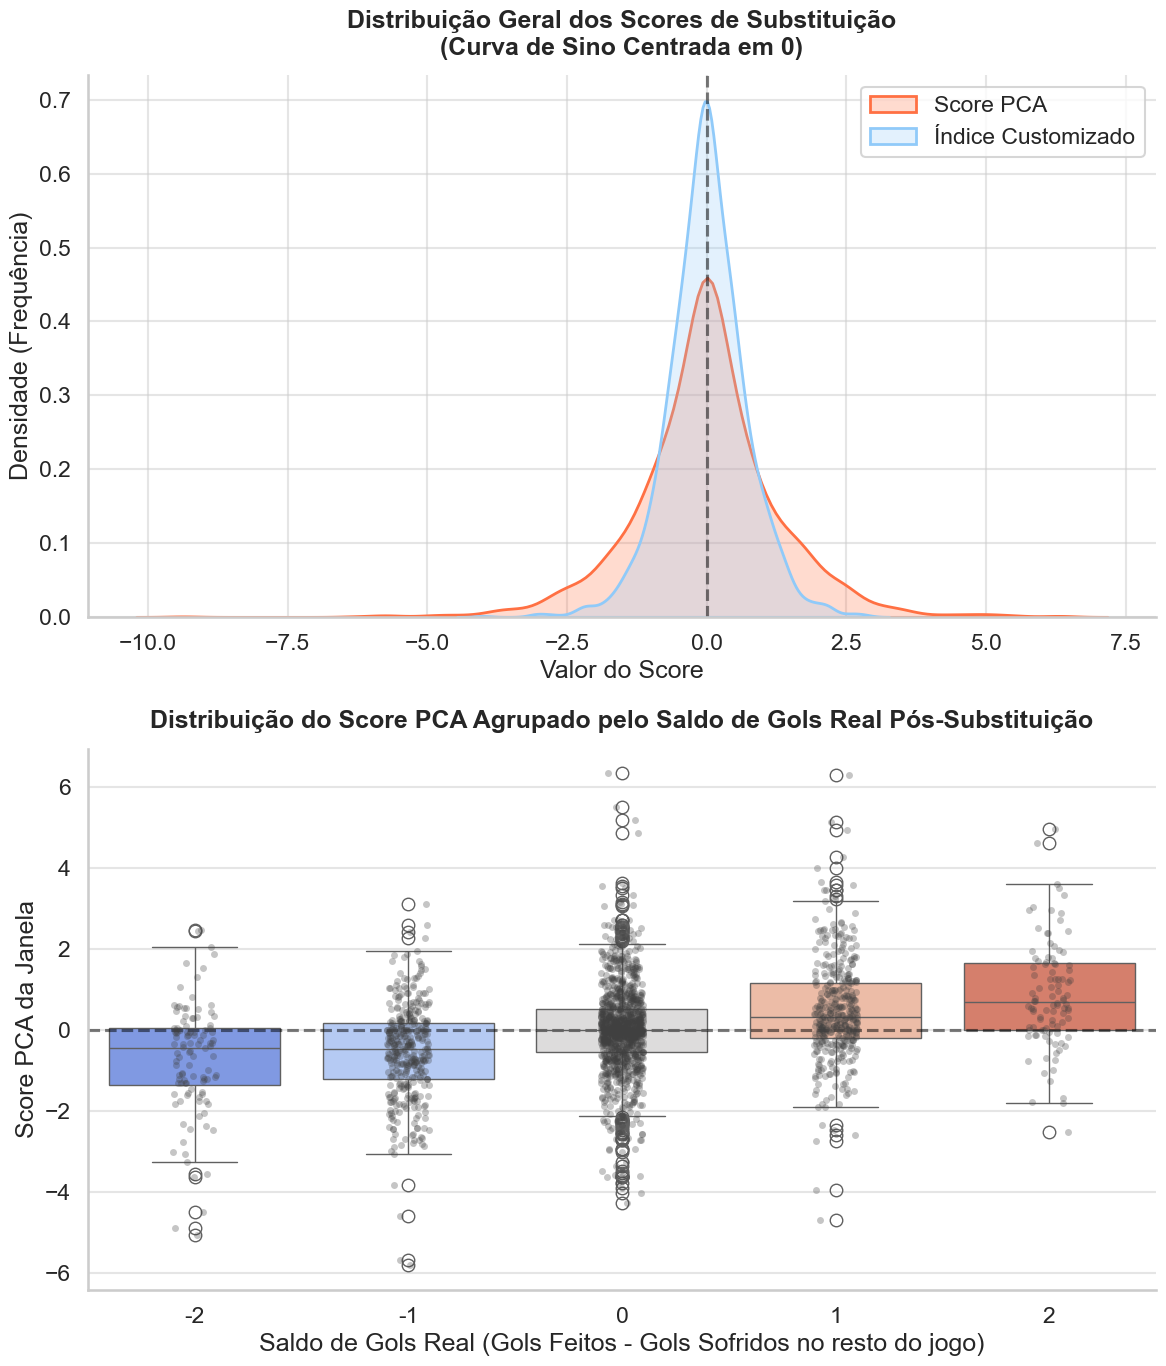

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_distributions_and_comparisons(df):
    # Configuração de estilo geral para os gráficos
    sns.set_theme(style="whitegrid", context="talk")
    
    # Cria uma figura com 2 subplots (um em cima do outro)
    fig, axes = plt.subplots(2, 1, figsize=(12, 14))
    
    # ==========================================
    # Gráfico 1: Distribuição dos Scores (KDE)
    # ==========================================
    # KDE (Kernel Density Estimate) é melhor que histograma para ver a suavidade da curva
    sns.kdeplot(data=df['score_pca'], ax=axes[0], fill=True, label='Score PCA', color='#FF7043', linewidth=2)
    sns.kdeplot(data=df['score_custom_index'], ax=axes[0], fill=True, label='Índice Customizado', color='#90CAF9', linewidth=2)
    
    axes[0].set_title('Distribuição Geral dos Scores de Substituição\n(Curva de Sino Centrada em 0)', pad=15, fontweight='bold')
    axes[0].set_xlabel('Valor do Score')
    axes[0].set_ylabel('Densidade (Frequência)')
    axes[0].legend()
    
    # Adiciona uma linha vertical no 0 (Ponto de neutralidade)
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)

    # ==========================================
    # Gráfico 2: Boxplot (Score PCA vs Saldo Real)
    # ==========================================
    # Vamos focar no PCA (o melhor modelo). Vamos ver como o score dele se distribui 
    # dependendo de qual foi o Saldo de Gols real após a substituição.
    
    # Para evitar gráficos poluídos, vamos limitar o saldo de gols entre -2 e +2
    # (Saldos maiores ou menores que isso em uma janela de substituição são outliers raros)
    df_filtered = df[(df['goal_diff_after_sub'] >= -2) & (df['goal_diff_after_sub'] <= 2)]
    
    sns.boxplot(x='goal_diff_after_sub', y='score_pca', data=df_filtered, ax=axes[1], palette='coolwarm')
    
    # Adicionando um 'stripplot' por cima adiciona os pontinhos reais, ajudando a ver o volume de dados
    sns.stripplot(x='goal_diff_after_sub', y='score_pca', data=df_filtered, ax=axes[1], color=".25", alpha=0.3, jitter=True)
    
    axes[1].set_title('Distribuição do Score PCA Agrupado pelo Saldo de Gols Real Pós-Substituição', pad=15, fontweight='bold')
    axes[1].set_xlabel('Saldo de Gols Real (Gols Feitos - Gols Sofridos no resto do jogo)')
    axes[1].set_ylabel('Score PCA da Janela')
    
    # Linha horizontal do zero no PCA
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

    # Ajusta o layout e exibe
    sns.despine()
    plt.tight_layout()
    plt.show()

# Chamando a função com o seu dataframe já com os scores calculados
plot_model_distributions_and_comparisons(df_scored)

In [118]:
from IPython.display import display

# 1. Lista com as métricas isoladas e o nosso modelo Vencedor (PCA)
scores_to_compare = [
    'pm_xG',             # Plus-Minus de xG isolado
    'pm_xT',             # Plus-Minus de xT isolado
    'pm_Vaep',           # Plus-Minus de Vaep isolado
    #'score_pca'          # O nosso Super Índice Matemático
    # 'goal_diff_after_sub' # Descomente se quiser ver o "Oráculo" (Correlação 1.0)
]

# 2. Executando a avaliação
comparison_results = evaluate_scores(df_scored, scores_to_compare, 'goal_diff_after_sub')

# 3. Ordenando pelo Lift (do maior para o menor) para facilitar a leitura
comparison_results = comparison_results.sort_values(by='Lift (Top - Bottom)', ascending=False).reset_index(drop=True)

# Exibindo a tabela com 4 casas decimais
display(comparison_results.round(4))

,Modelo,Spearman_Corr,P_Value,Avg_Goal_Diff_Top25%,Avg_Goal_Diff_Bottom25%,Lift (Top - Bottom)
0,pm_xG,0.3998,0.0000,0.5000,-0.5318,1.0318
1,pm_xT,0.2578,0.0000,0.3352,-0.3652,0.7004
2,pm_Vaep,-0.0072,0.7411,0.0337,0.0094,0.0243


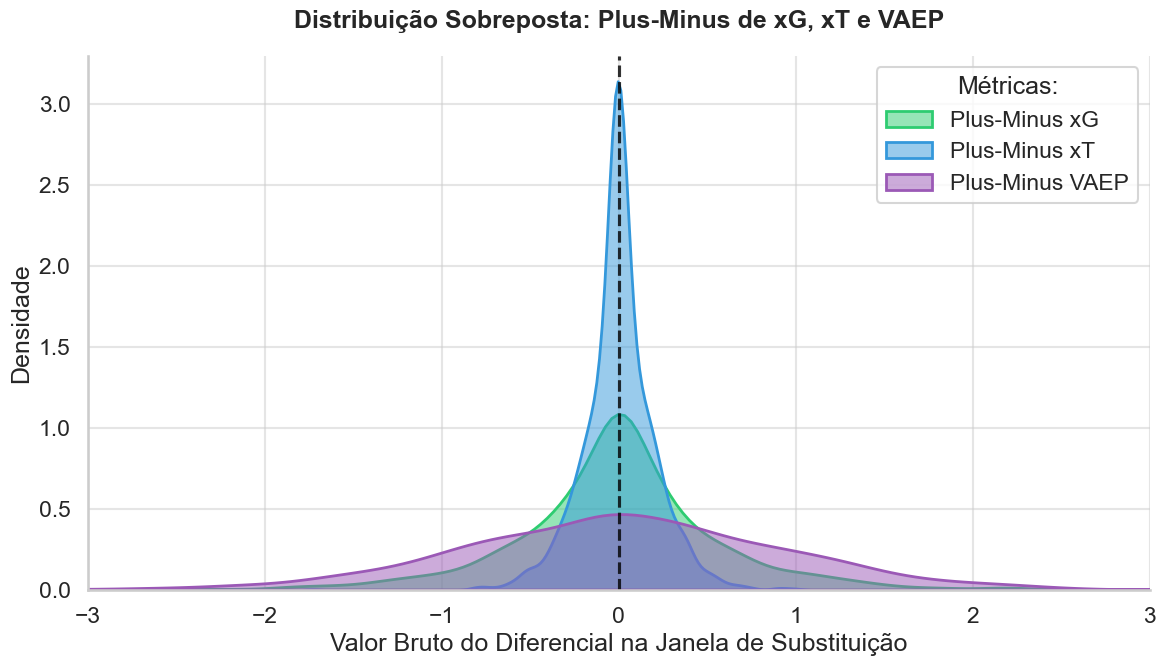

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_overlapped_metrics(df):
    """
    Gera um gráfico de densidade (KDE) único com as três métricas sobrepostas.
    """
    # Configuração de estilo geral para os gráficos
    sns.set_theme(style="whitegrid", context="talk")
    
    plt.figure(figsize=(12, 7))
    
    # Cores distintas para cada métrica com alpha para transparência
    sns.kdeplot(data=df['pm_xG'], fill=True, label='Plus-Minus xG', color='#2ecc71', alpha=0.5, linewidth=2)
    sns.kdeplot(data=df['pm_xT'], fill=True, label='Plus-Minus xT', color='#3498db', alpha=0.5, linewidth=2)
    sns.kdeplot(data=df['pm_Vaep'], fill=True, label='Plus-Minus VAEP', color='#9b59b6', alpha=0.5, linewidth=2)
    
    plt.title('Distribuição Sobreposta: Plus-Minus de xG, xT e VAEP', pad=20, fontweight='bold')
    plt.xlabel('Valor Bruto do Diferencial na Janela de Substituição')
    plt.ylabel('Densidade')
    
    # Linha do zero para referência
    plt.axvline(0, color='black', linestyle='--', alpha=0.8)
    
    # Limitando o eixo X para focar no "miolo" dos dados e evitar outliers bizarros
    # Ajuste esses valores caso os seus dados tenham escalas maiores
    plt.xlim(-3, 3) 
    
    plt.legend(title='Métricas:')
    sns.despine()
    plt.tight_layout()
    plt.show()

# Executando a função passando o seu dataframe
plot_overlapped_metrics(df_scored)

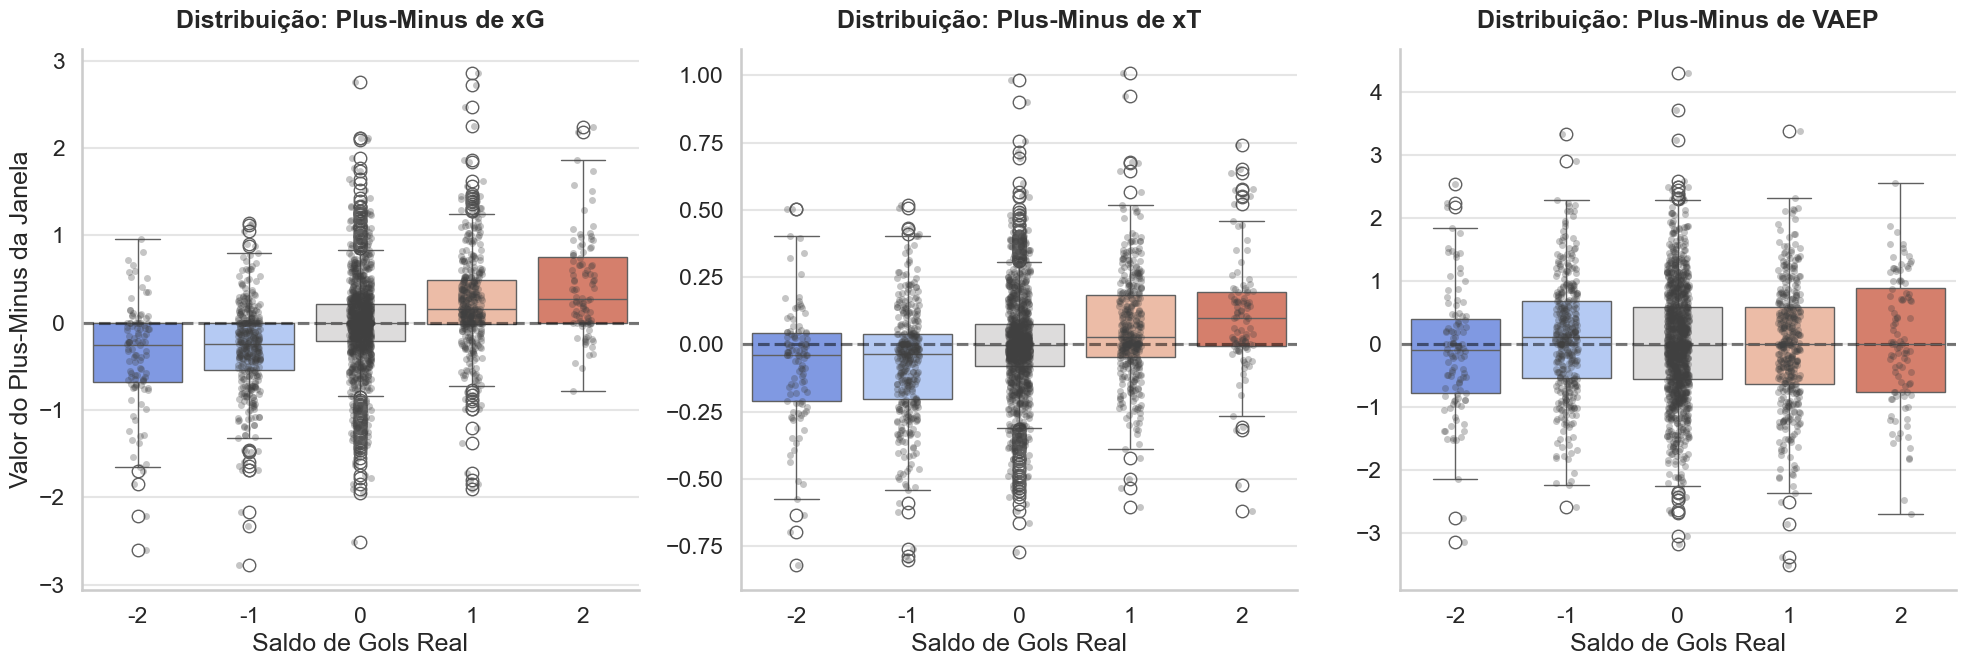

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics_boxplots(df):
    """
    Gera boxplots agrupados pelo Saldo de Gols para as métricas individuais (xG, xT, Vaep).
    """
    # Configuração de estilo geral
    sns.set_theme(style="whitegrid", context="talk")
    
    # Filtra os outliers de saldo de gols para limpar os gráficos (focando de -2 a +2)
    df_filtered = df[(df['goal_diff_after_sub'] >= -2) & (df['goal_diff_after_sub'] <= 2)]
    
    # Cria uma figura com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    # Listas para facilitar o loop
    metrics = ['pm_xG', 'pm_xT', 'pm_Vaep']
    titles = ['Plus-Minus de xG', 'Plus-Minus de xT', 'Plus-Minus de VAEP']
    
    for i, metric in enumerate(metrics):
        # 1. Desenha o Boxplot
        sns.boxplot(x='goal_diff_after_sub', y=metric, data=df_filtered, ax=axes[i], palette='coolwarm')
        
        # 2. Desenha os pontinhos (Stripplot) por cima
        sns.stripplot(x='goal_diff_after_sub', y=metric, data=df_filtered, ax=axes[i], color=".25", alpha=0.3, jitter=True)
        
        # 3. Textos e Rótulos
        axes[i].set_title(f'Distribuição: {titles[i]}', pad=15, fontweight='bold')
        axes[i].set_xlabel('Saldo de Gols Real')
        
        # Coloca o label do eixo Y apenas no primeiro gráfico para não poluir
        if i == 0:
            axes[i].set_ylabel('Valor do Plus-Minus da Janela')
        else:
            axes[i].set_ylabel('')
        
        # 4. Linha horizontal do zero (ponto neutro)
        axes[i].axhline(0, color='black', linestyle='--', alpha=0.5)

    # Ajusta o espaçamento para não sobrepor nada e exibe
    sns.despine()
    plt.tight_layout()
    plt.show()

# Executando a função passando o seu dataframe
plot_metrics_boxplots(df_scored)

In [121]:
df_scored.columns

Index(['match_id', 'team_id', 'opp_team_id', 'minute',
       'window_duration_seconds', 'positions_out', 'positions_in',
       'team_score_at_sub', 'opp_score_at_sub', 'score_string_at_sub',
       'team_score_at_end', 'opp_score_at_end', 'goal_diff_after_sub', 'pm_xG',
       'pm_xT', 'pm_Vaep', 'out_xG_before_sub', 'out_xT_before_sub',
       'out_Vaep_before_sub', 'in_xG_after_sub', 'in_xT_after_sub',
       'in_Vaep_after_sub', 'score_pca', 'score_custom_index', 'quartile'],
      dtype='str')

In [122]:
from IPython.display import display

def visualizar_tabela_scores(df):
    """
    Gera uma tabela limpa e formatada comparando as métricas originais
    e os scores dos modelos para cada janela de substituição.
    """
    # 1. Selecionando as colunas de contexto e de avaliação
    colunas_foco = [
        'match_id', 'team_id', 'positions_out', 'positions_in', 'minute', 'team_score_at_sub', 'score_string_at_sub', 'goal_diff_after_sub', # Contexto e Realidade
        'pm_xG', 'pm_xT', 'pm_Vaep',                            # Plus-Minus Originais
        'score_pca', 'score_custom_index'                       # Modelos Compostos
    ]
    
    # Criando um novo dataframe apenas com essas colunas
    tabela_comparativa = df[colunas_foco].copy()
    
    # 2. Arredondando os valores decimais para facilitar a leitura (2 casas)
    colunas_metricas = ['pm_xG', 'pm_xT', 'pm_Vaep', 'score_pca', 'score_custom_index']
    tabela_comparativa[colunas_metricas] = tabela_comparativa[colunas_metricas].round(2)
    
    # 3. Ordenando pelas melhores substituições segundo o seu melhor modelo (PCA)
    tabela_comparativa = tabela_comparativa.sort_values(by='score_pca', ascending=False).reset_index(drop=True)
    
    # Exibindo as 15 "Melhores" janelas de substituição
    print("=== TOP 15 JANELAS DE SUBSTITUIÇÃO (Ordenado por PCA) ===")
    display(tabela_comparativa.head(15))
    
    # Descomente a linha abaixo se quiser ver as 15 "Piores" também
    # print("\n=== BOTTOM 15 JANELAS DE SUBSTITUIÇÃO (Ordenado por PCA) ===")
    # display(tabela_comparativa.tail(15))

# Executando a função
visualizar_tabela_scores(df_scored)

=== TOP 15 JANELAS DE SUBSTITUIÇÃO (Ordenado por PCA) ===


,match_id,team_id,positions_out,positions_in,minute,team_score_at_sub,score_string_at_sub,goal_diff_after_sub,pm_xG,pm_xT,pm_Vaep,score_pca,score_custom_index
0,32135,3.0000,"[CF, CM, LB, RW]","[CF, CM, LB, LW]",62,1,1x0,0,2.7600,0.9800,-1.4200,6.3300,2.2000
1,32175,3.0000,[LCB],[LCB],22,0,0x1,1,2.7300,1.0100,-1.9600,6.2900,2.0000
2,32361,8.0000,[RB],[RB],18,1,1x0,3,2.2500,0.8900,-0.7300,5.5300,2.1500
3,32349,12.0000,"[DM, AM]","[LB, LW]",64,0,0x2,0,2.0900,0.9000,0.2100,5.5100,2.5100
4,32213,221.0000,[LW],[RW],40,2,2x0,0,2.1200,0.7600,0.9400,5.1700,2.5600
5,32235,3.0000,[RW],[AM],71,0,0x1,1,2.2500,0.6800,1.3900,5.1300,2.6400
6,32285,2.0000,[LCB],[LCB],18,0,0x0,2,1.8600,0.7400,1.7800,4.9500,2.8100
7,32012,13.0000,"[CM, LCB]","[CM, LB]",75,0,0x1,1,1.3900,0.9200,1.3100,4.9400,2.8000
8,32046,2.0000,[DM],[RW],92,2,2x2,0,2.1200,0.6900,0.2400,4.8500,2.1300
9,32114,10.0000,"[CM, LW]","[CM, LW]",68,1,1x2,2,2.1900,0.6400,-0.6700,4.6100,1.6600
